In [20]:
import pandas as pd
import sqlite3
import scipy.stats as stats
from scipy.stats import normaltest, skew, ttest_ind, mannwhitneyu, gaussian_kde , pearsonr, spearmanr
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
conn_second = sqlite3.connect("basketball.db")
conn_main = sqlite3.connect("basketball_reference.db")

df_seasons = pd.read_sql_query("SELECT * FROM seasons", conn_second)
df_team_stats = pd.read_sql_query("SELECT * FROM team_stats", conn_second)

df_seasons.to_sql("seasons", conn_main, if_exists="replace", index=False)
df_team_stats.to_sql("team_stats", conn_main, if_exists="replace", index=False)

conn_second.close()
conn_main.close()

In [3]:
conn = sqlite3.connect("basketball_reference.db")

tables = [
    "seasons", "teams", "team_stats", "players", "player_position", 
    "coaches", "awards", "award_season", "player_stats", "coach_stats"
]
dfs = {}
for table in tables:
    dfs[table] = pd.read_sql_query(f"SELECT * FROM {table};", conn)

In [4]:
for name, df in dfs.items():
    print(f"====================\n{name} Table\n====================")
    display(df.describe())
    print(df.info())

seasons Table


,season_id,league_avg_pts
count,5.000000,5.000000
mean,2022.000000,112.680000
std,1.581139,1.719593
min,2020.000000,110.600000
25%,2021.000000,111.800000
50%,2022.000000,112.100000
75%,2023.000000,114.200000
max,2024.000000,114.700000


<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   season_id             5 non-null      int64  
 1   season_name           5 non-null      str    
 2   champion_id           5 non-null      str    
 3   runner_up_id          5 non-null      str    
 4   league_avg_pts        5 non-null      float64
 5   mvp_player_id         5 non-null      str    
 6   finals_mvp_player_id  5 non-null      str    
dtypes: float64(1), int64(1), str(5)
memory usage: 412.0 bytes
None
teams Table


,team_id,name,city,state
count,30,30,30,30
unique,30,30,29,23
top,MIL,Bucks,Los Angeles,California
freq,1,1,2,4


<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   team_id  30 non-null     str  
 1   name     30 non-null     str  
 2   city     30 non-null     str  
 3   state    30 non-null     str  
dtypes: str(4)
memory usage: 1.1 KB
None
team_stats Table


...

<class 'pandas.DataFrame'>
RangeIndex: 3072 entries, 0 to 3071
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   id         3072 non-null   int64
 1   season_id  3072 non-null   int64
 2   award_id   3072 non-null   str  
 3   player_id  3072 non-null   str  
dtypes: int64(2), str(2)
memory usage: 96.1 KB
None
player_stats Table


,id,season_id,games,games_started,minutes_played,field_goals,field_goal_attempts,field_goal_percent,three_point_field_goals,three_point_field_goal_attempts,...,total_rebounds,assists,steals,blocks,turnovers,personal_fouls,points,triple_doubles,win_shares,experience
count,3801.000000,3801.000000,3801.000000,3801.000000,3801.000000,3801.000000,3801.000000,3801.000000,3801.000000,3801.000000,...,3801.000000,3801.000000,3801.000000,3801.000000,3801.000000,3801.000000,3801.000000,3801.000000,3801.000000,3801.000000
mean,1901.000000,2022.058669,36.964483,16.858721,830.321757,140.875822,302.248356,0.416867,42.923967,119.248356,...,151.143383,86.292555,25.911076,16.644830,45.523546,67.777690,383.867666,0.176006,1.717548,5.552223
std,1097.398515,1.400744,25.333721,23.588072,764.487881,157.600327,330.439321,0.159110,54.643368,144.198288,...,165.251238,113.599294,26.344439,23.294344,52.110788,60.721442,434.955306,1.418046,2.278877,4.184366
min,1.000000,2020.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.900000,0.000000
25%,951.000000,2021.000000,13.000000,0.000000,128.000000,16.000000,38.000000,0.386000,2.000000,8.000000,...,21.000000,8.000000,4.000000,2.000000,6.000000,13.000000,43.000000,0.000000,0.100000,2.000000
50%,1901.000000,2022.000000,37.000000,4.000000,609.000000,84.000000,188.000000,0.439000,19.000000,60.000000,...,100.000000,45.000000,17.000000,9.000000,28.000000,54.000000,227.000000,0.000000,0.800000,5.000000
75%,2851.000000,2023.000000,60.000000,27.000000,1403.000000,218.000000,469.000000,0.493000,66.000000,189.000000,...,229.000000,114.000000,42.000000,22.000000,66.000000,111.000000,593.000000,0.000000,2.600000,8.000000
max,3801.000000,2024.000000,84.000000,83.000000,2989.000000,837.000000,1652.000000,1.000000,357.000000,876.000000,...,1120.000000,763.000000,150.000000,254.000000,312.000000,286.000000,2370.000000,38.000000,17.000000,21.000000


<class 'pandas.DataFrame'>
RangeIndex: 3801 entries, 0 to 3800
Data columns (total 32 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   id                               3801 non-null   int64  
 1   season_id                        3801 non-null   int64  
 2   player_id                        3801 non-null   str    
 3   team_id                          3801 non-null   str    
 4   games                            3801 non-null   int64  
 5   games_started                    3801 non-null   int64  
 6   minutes_played                   3801 non-null   int64  
 7   field_goals                      3801 non-null   int64  
 8   field_goal_attempts              3801 non-null   int64  
 9   field_goal_percent               3801 non-null   float64
 10  three_point_field_goals          3801 non-null   int64  
 11  three_point_field_goal_attempts  3801 non-null   int64  
 12  three_point_field_goal_percent 

,id,wins_under_coach,losses_under_coach
count,163.000000,163.000000,163.000000
mean,82.000000,35.957055,36.269939
std,47.198164,14.079733,12.271145
min,1.000000,2.000000,5.000000
25%,41.500000,26.000000,29.000000
50%,82.000000,38.000000,36.000000
75%,122.500000,47.000000,43.000000
max,163.000000,64.000000,68.000000


<class 'pandas.DataFrame'>
RangeIndex: 163 entries, 0 to 162
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   id                  163 non-null    int64
 1   season_id           163 non-null    str  
 2   coach_id            163 non-null    str  
 3   team_id             163 non-null    str  
 4   wins_under_coach    163 non-null    int64
 5   losses_under_coach  163 non-null    int64
dtypes: int64(3), str(3)
memory usage: 7.8 KB
None


In [5]:
def plot_numeric_distributions(df, name, bins=None):
    numeric_cols = []

    for col in df.columns:
        dtype_name = df[col].dtype.name
        if "int" in dtype_name or "float" in dtype_name:
            numeric_cols.append(col)

    for col in numeric_cols:
        fig, axes = plt.subplots(2, 1,figsize=(12, 8))
        data = df[col].dropna()

        # Histogram
        _, bin_edges, _ = axes[0].hist(data, bins=bins, alpha=0.6)
        # Mean & median
        mean = data.mean()
        median = data.median()
        axes[0].axvline(mean, color="red", linestyle="--", label="Mean")
        axes[0].axvline(median, color="green", linestyle="-.", label="Median")
        # KDE
        x = np.linspace(data.min(), data.max())
        kde = gaussian_kde(data)
        bin_width = bin_edges[1] - bin_edges[0]
        axes[0].plot(x, kde(x) * len(data) * bin_width, label="KDE")
        axes[0].legend()

        # Box plot
        axes[1].boxplot(data, vert=False)
        axes[1].set_xticks([])

        axes[0].set_title(f"{name} - {col}")
        plt.show()

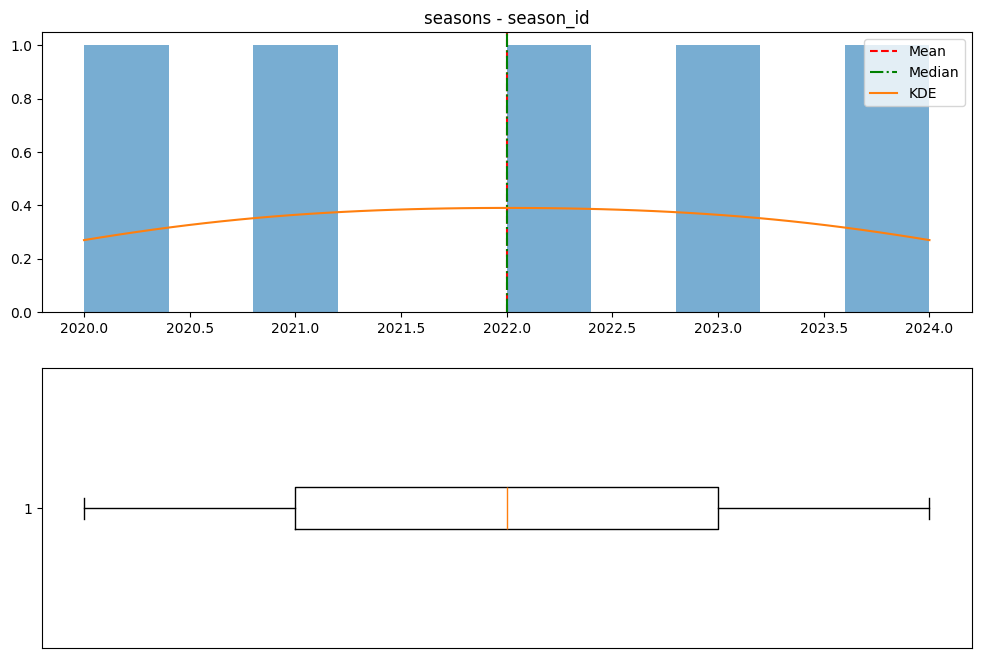

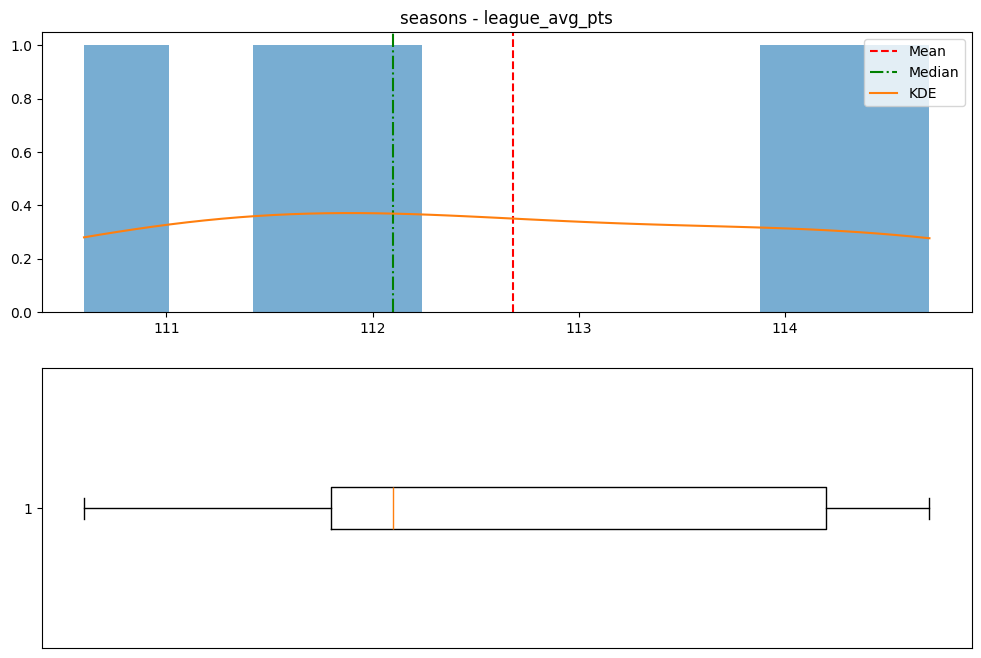

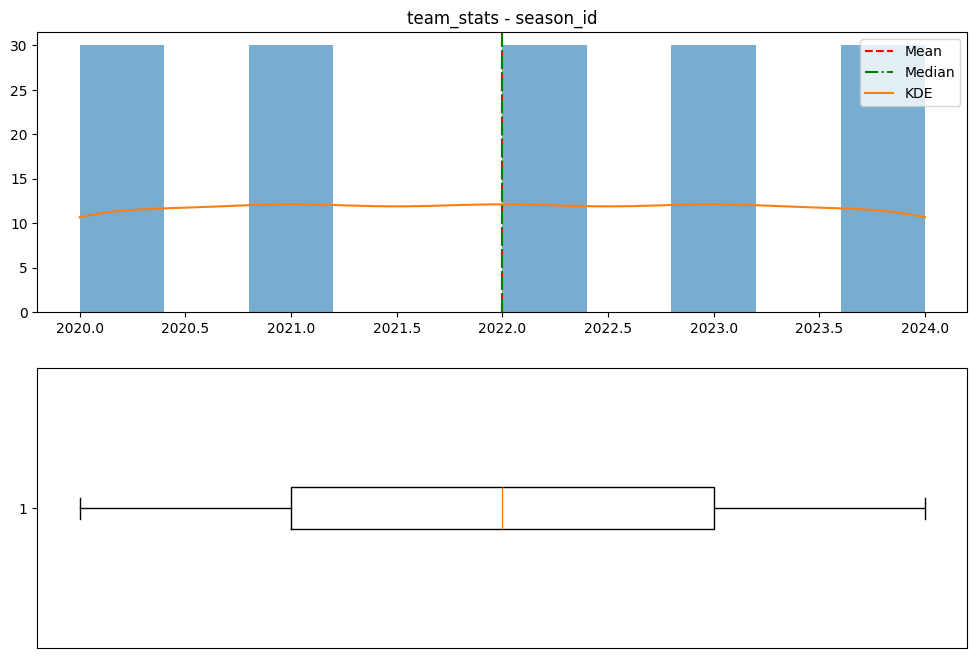

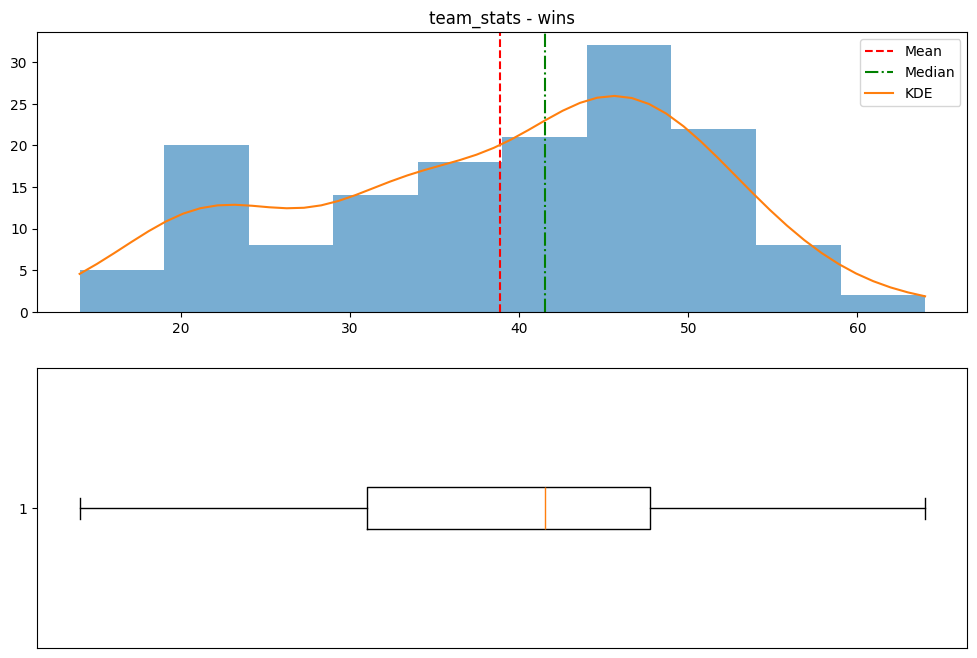

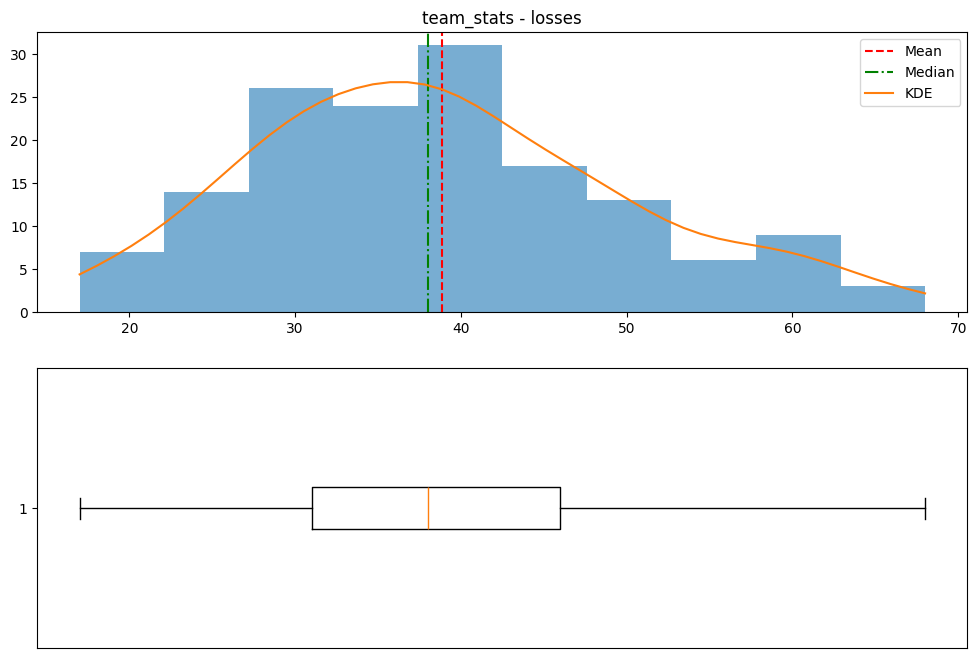

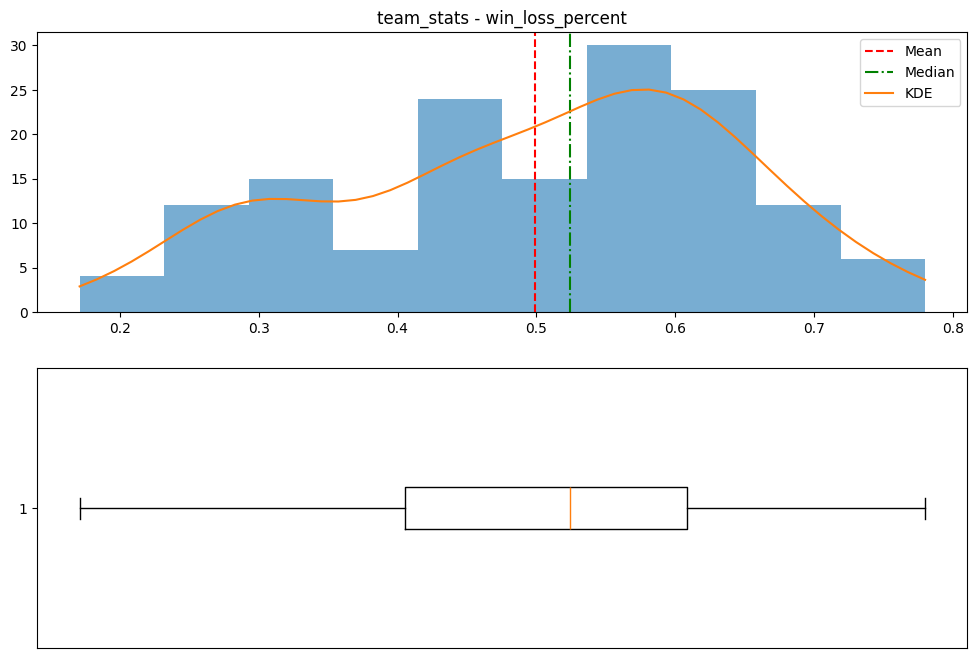

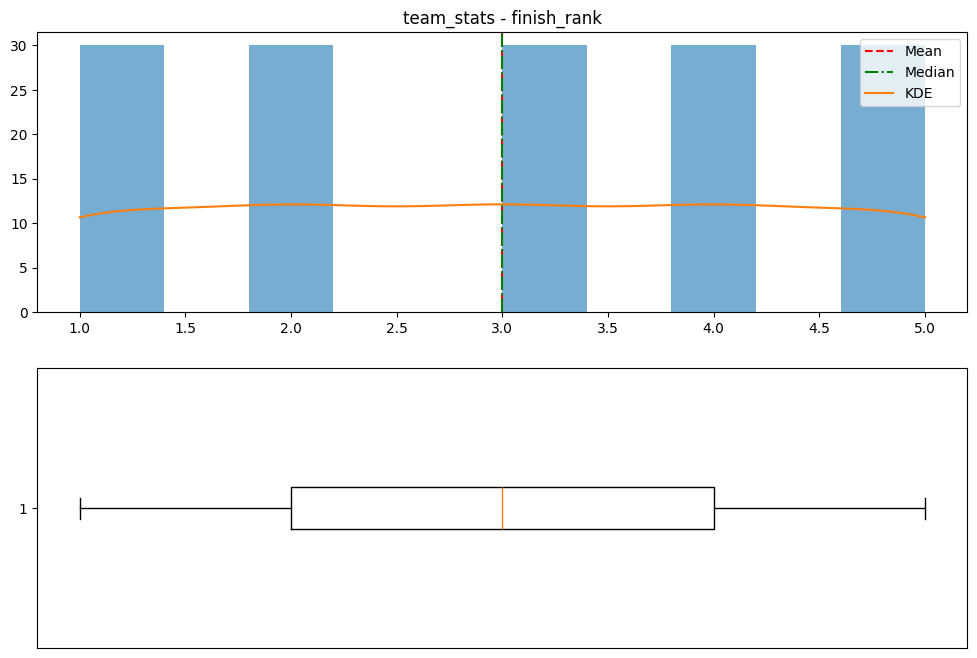

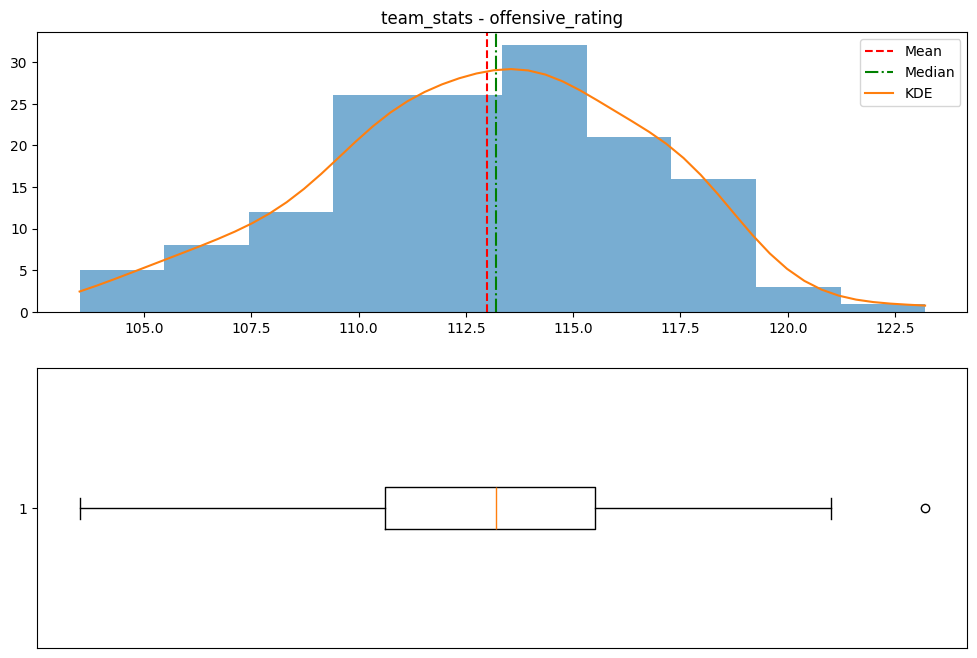

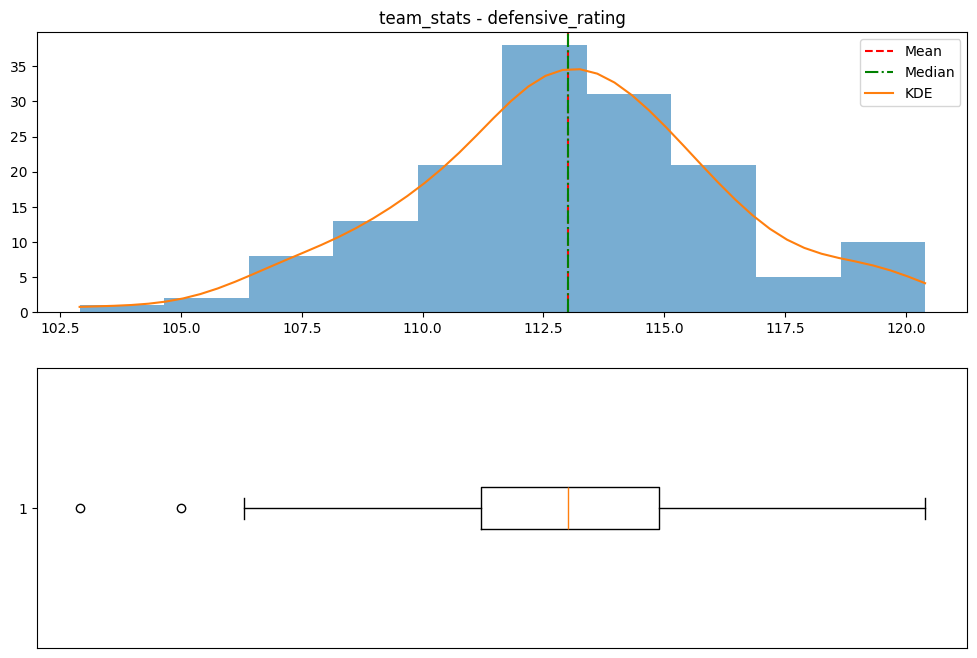

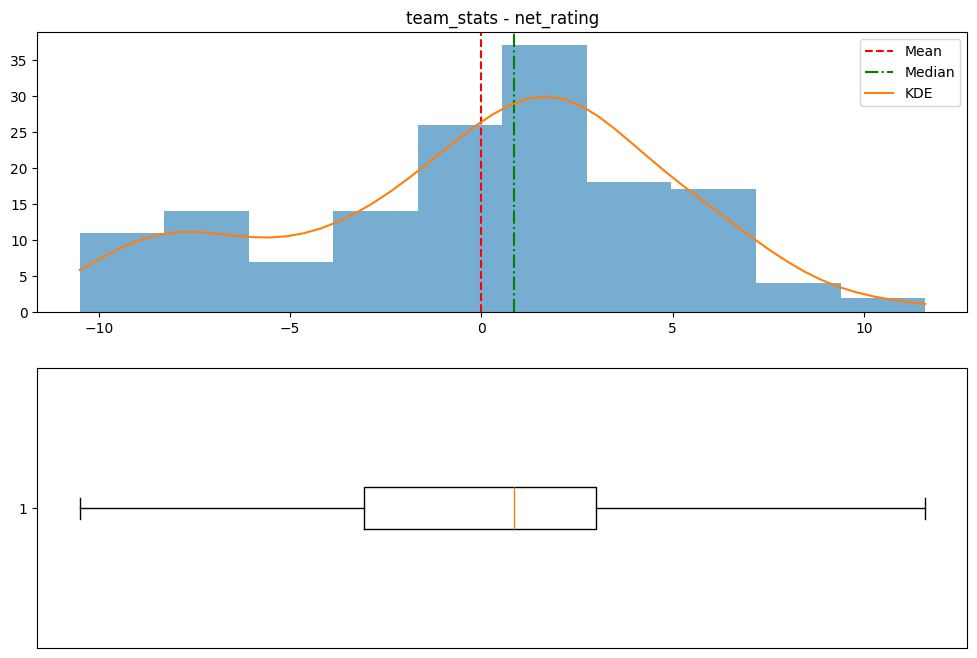

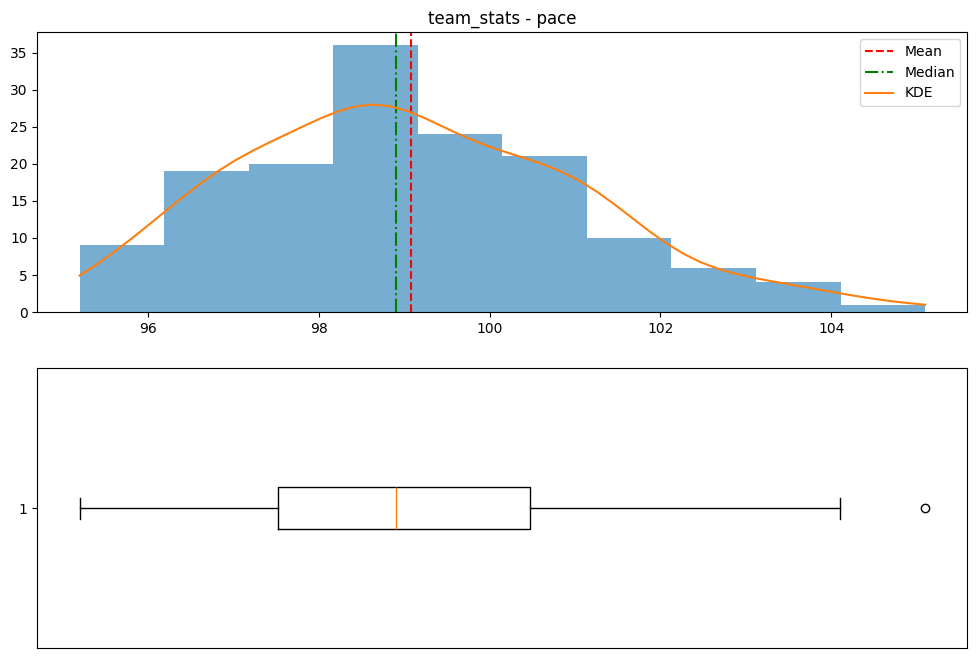

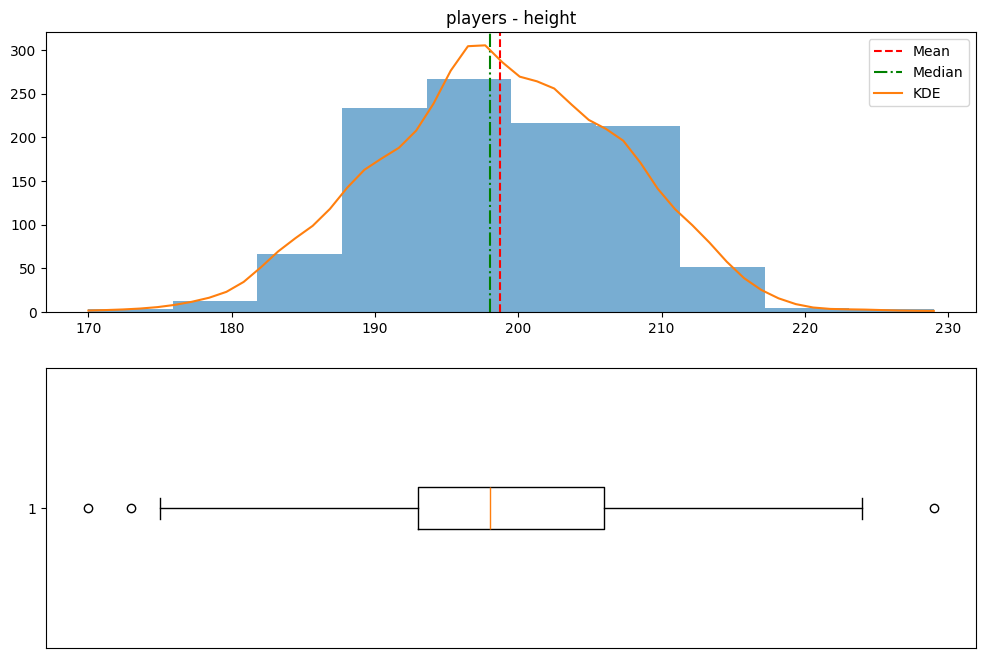

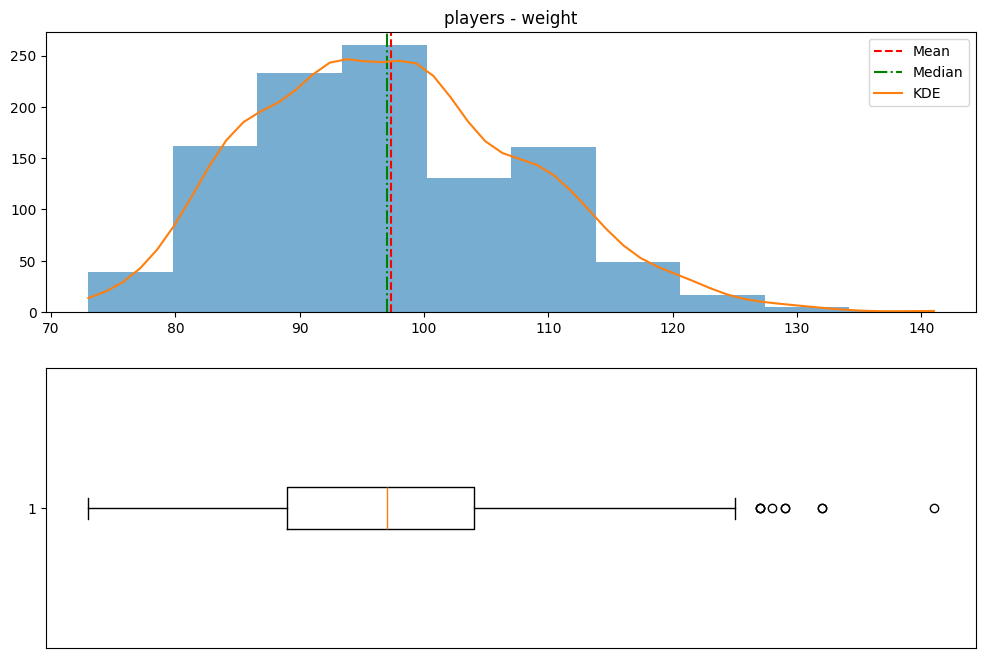

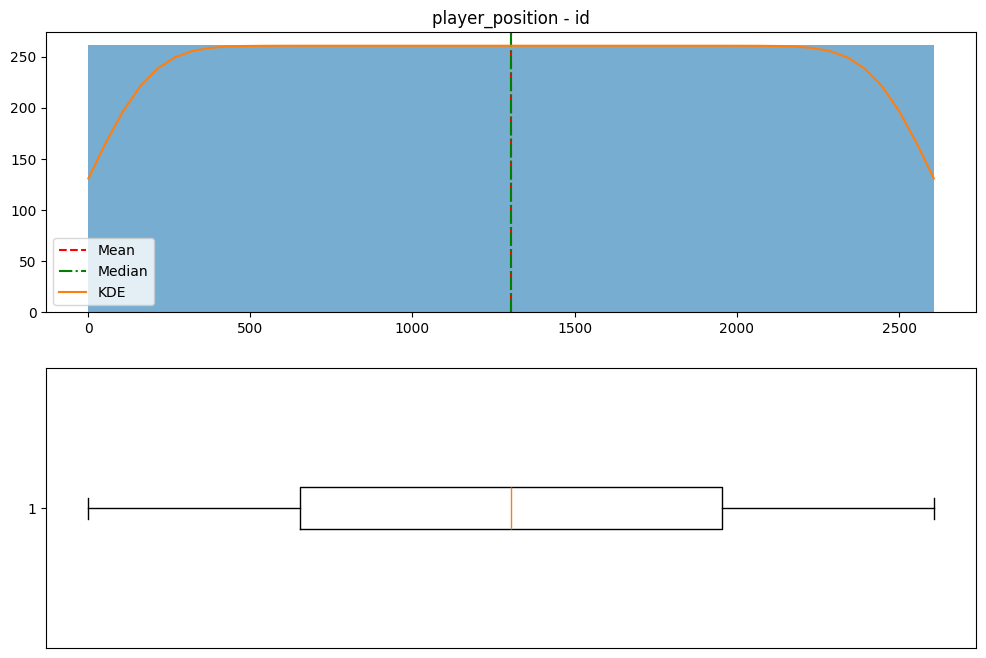

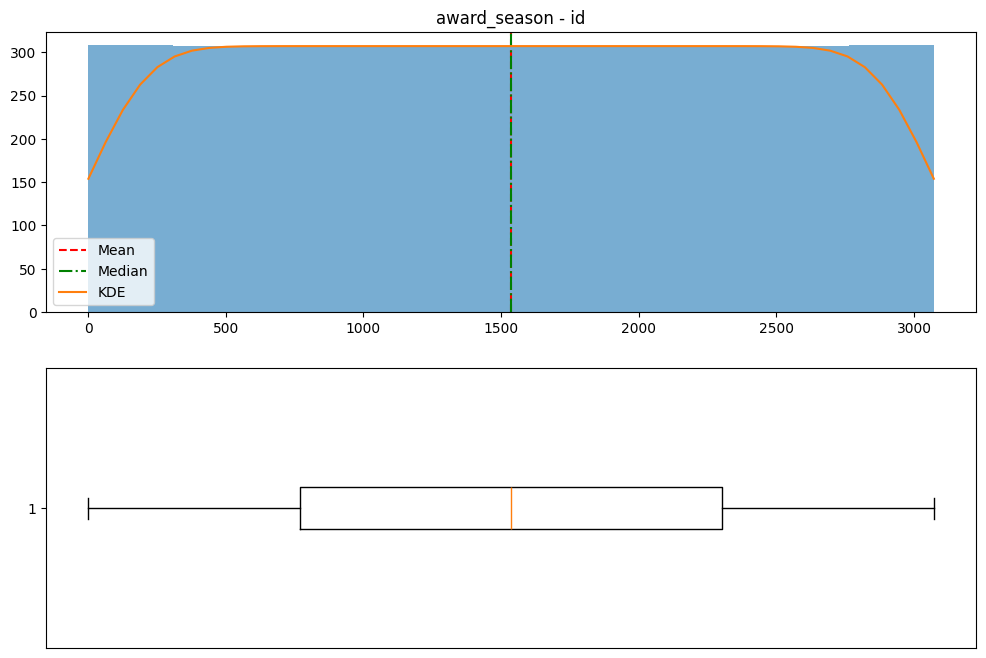

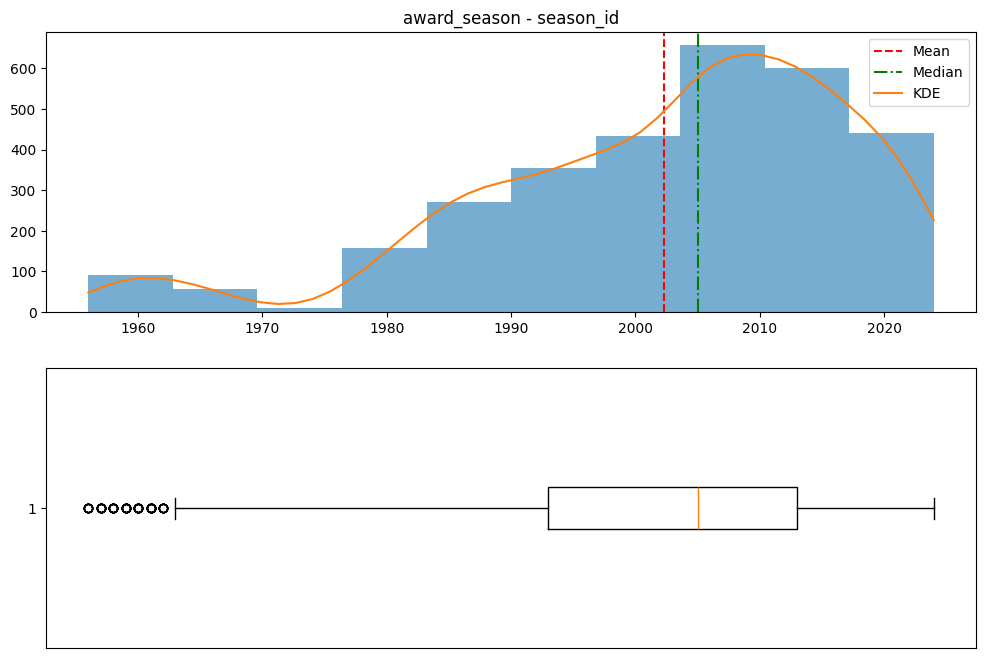

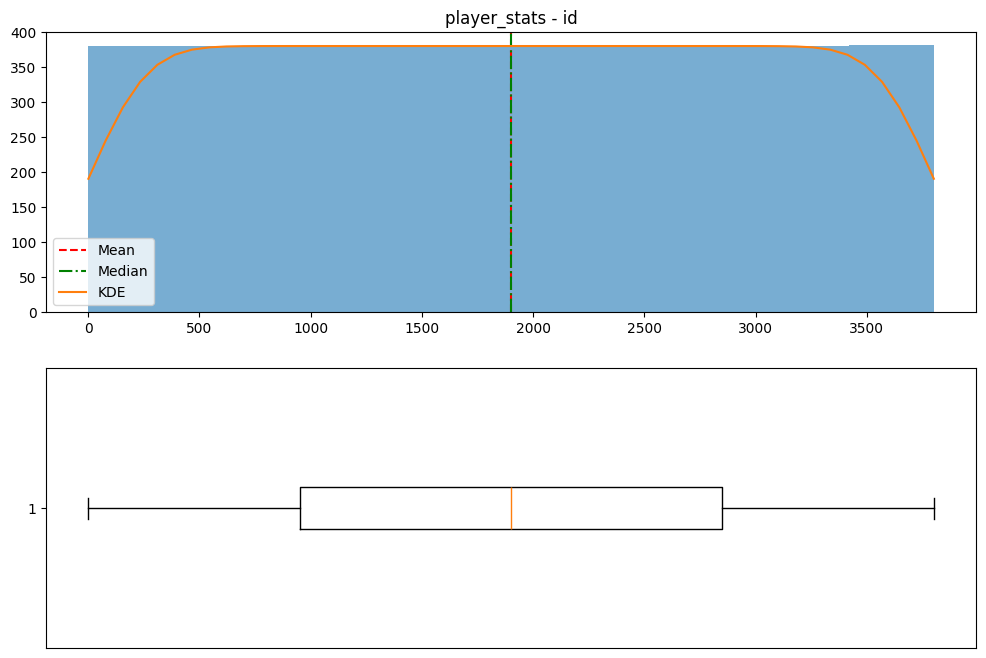

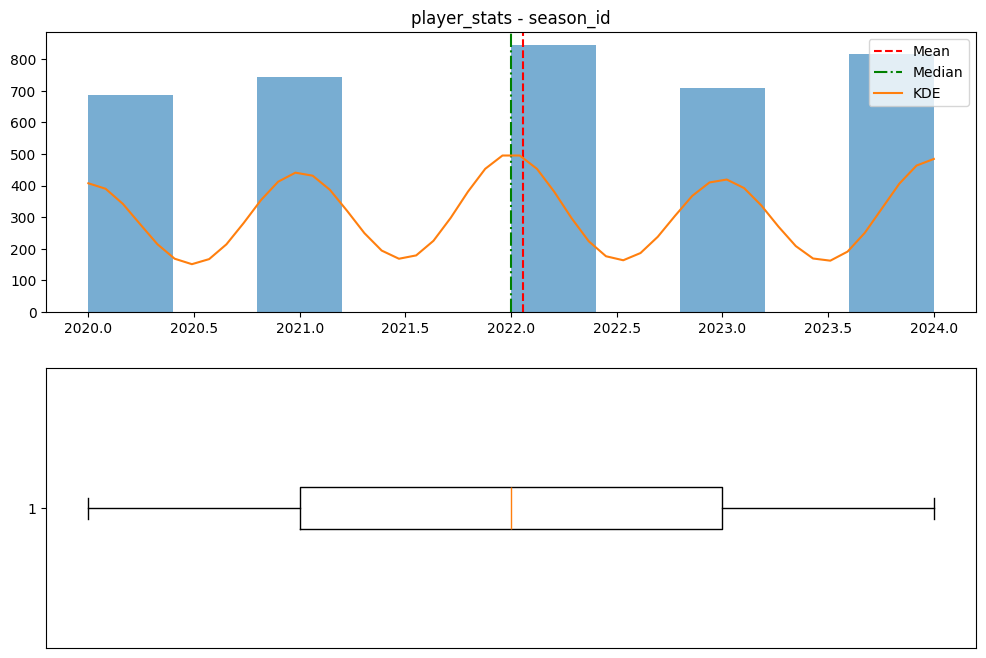

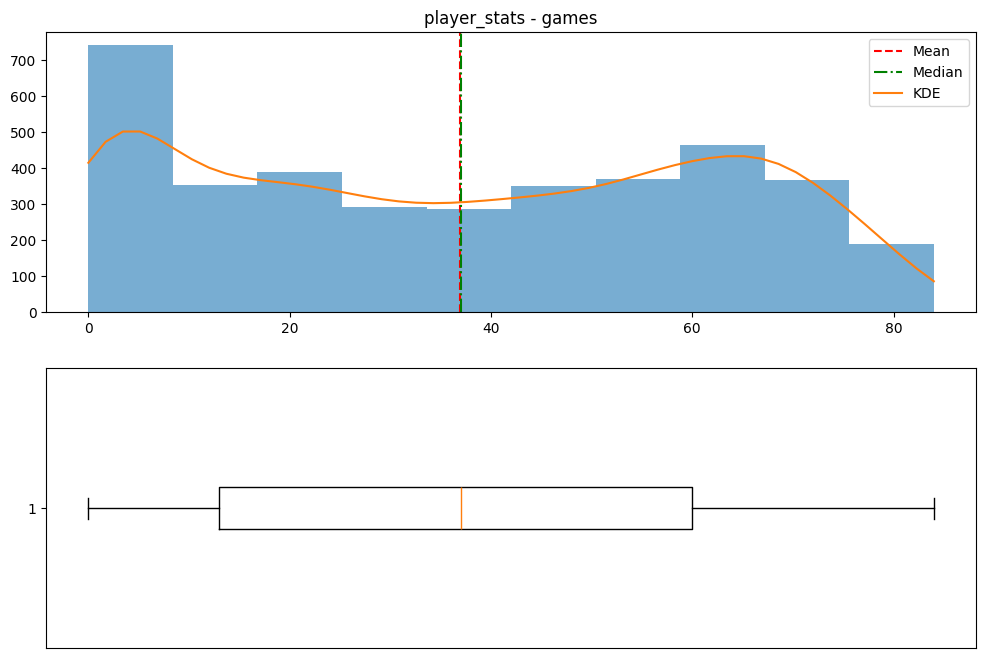

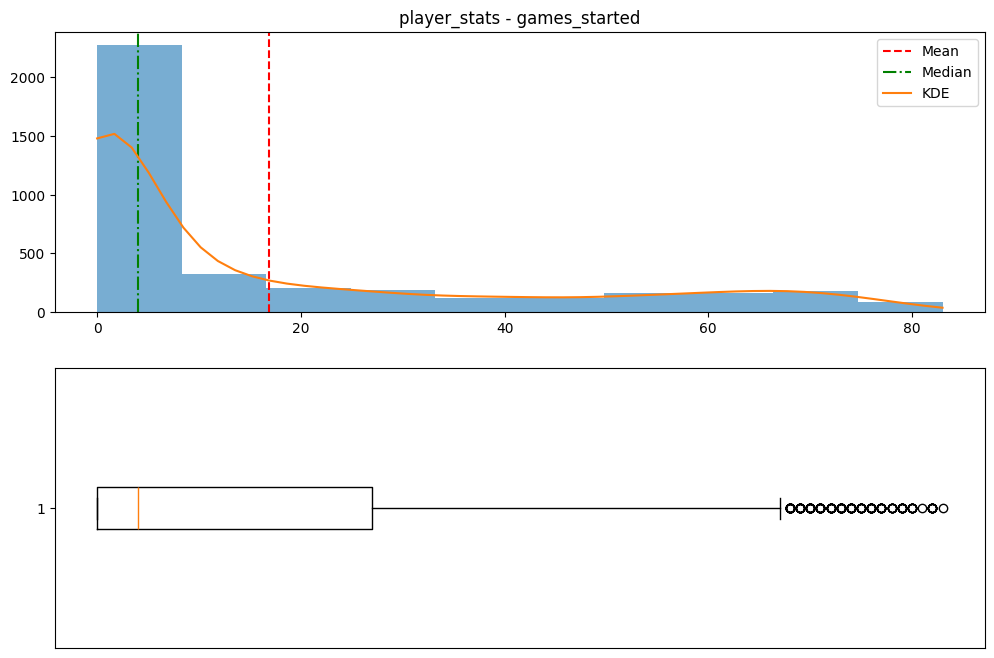

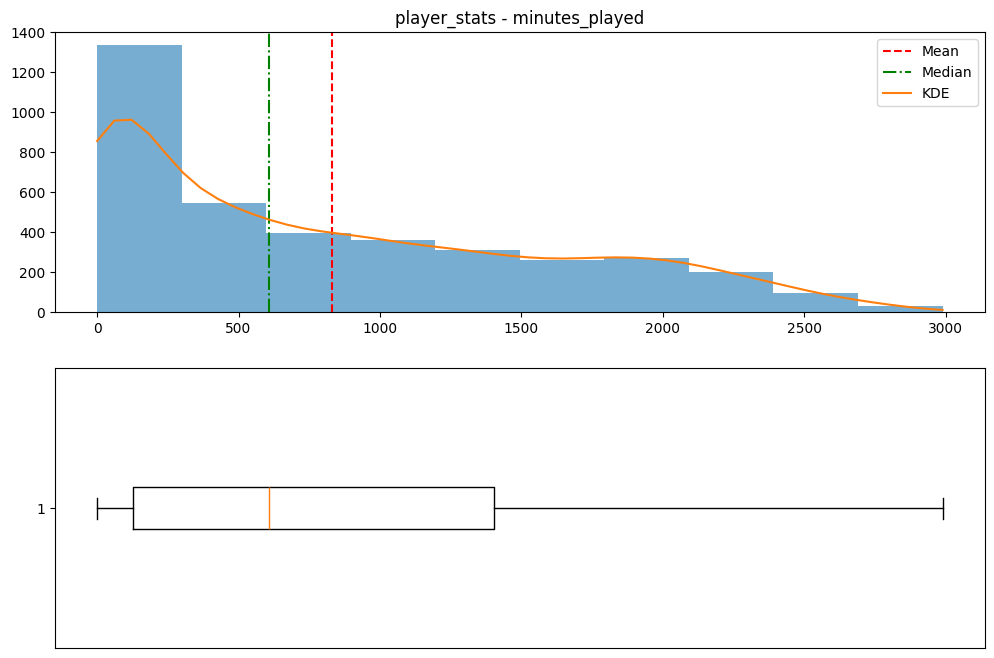

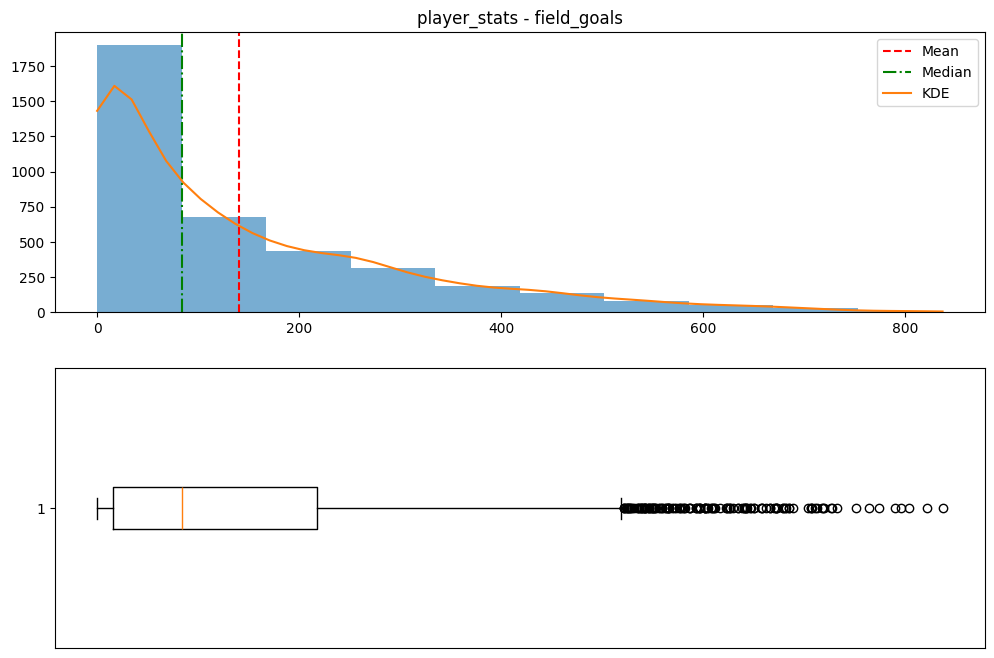

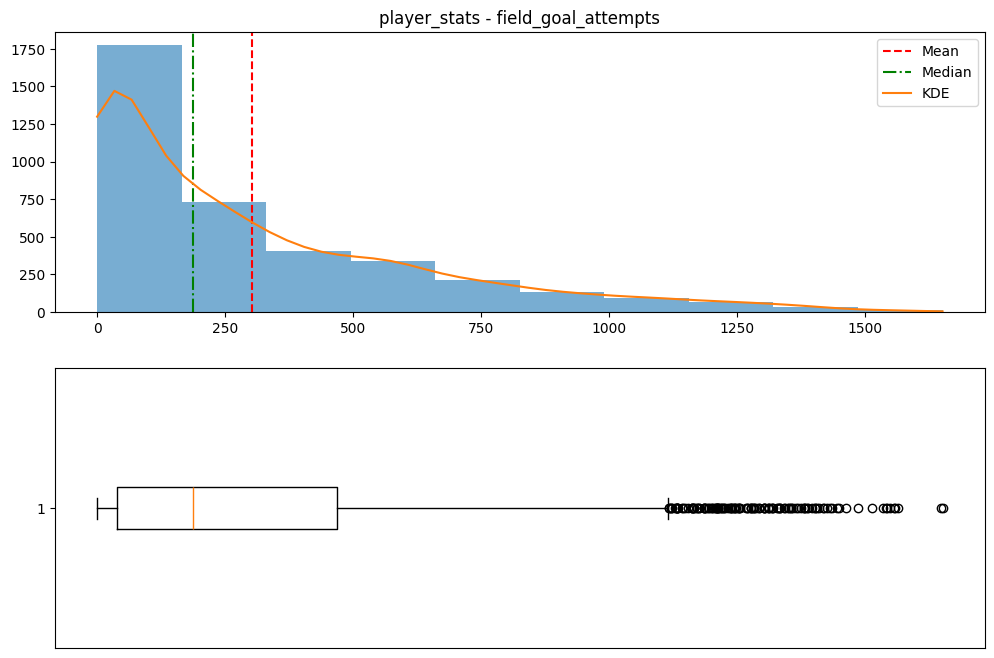

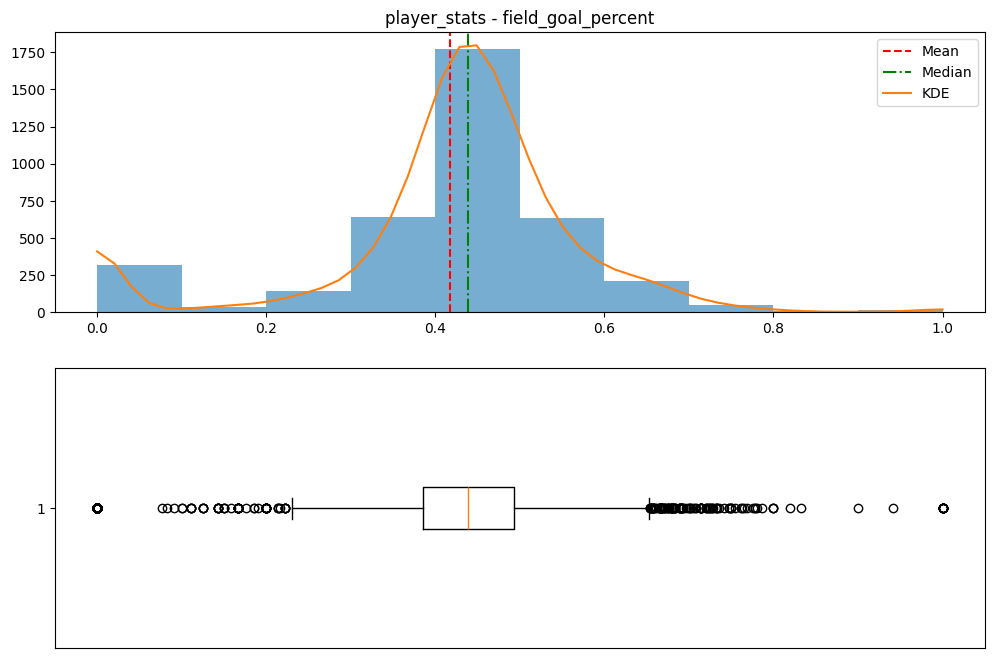

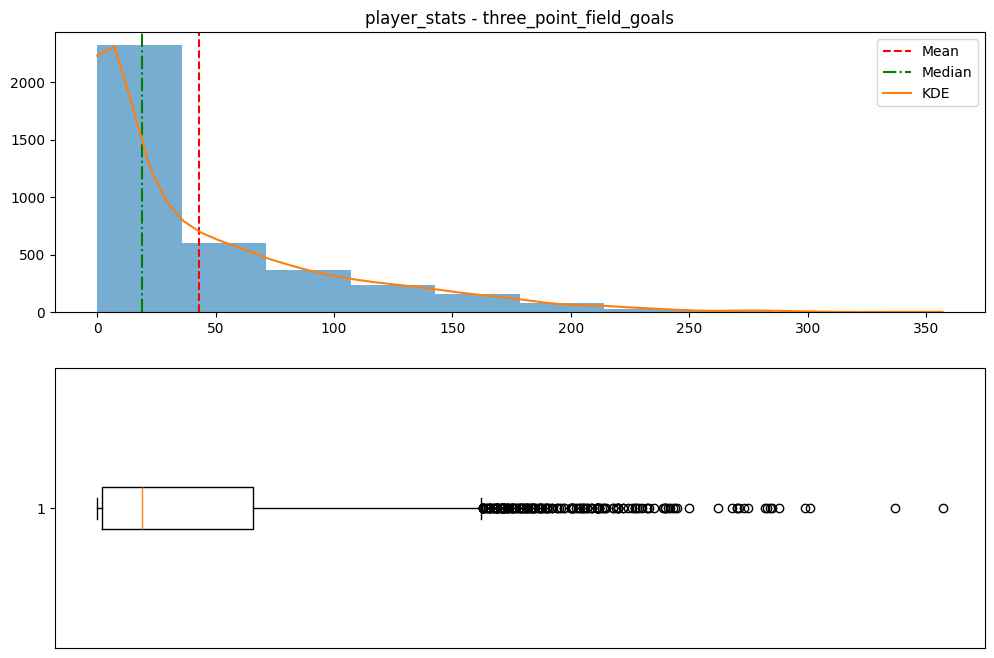

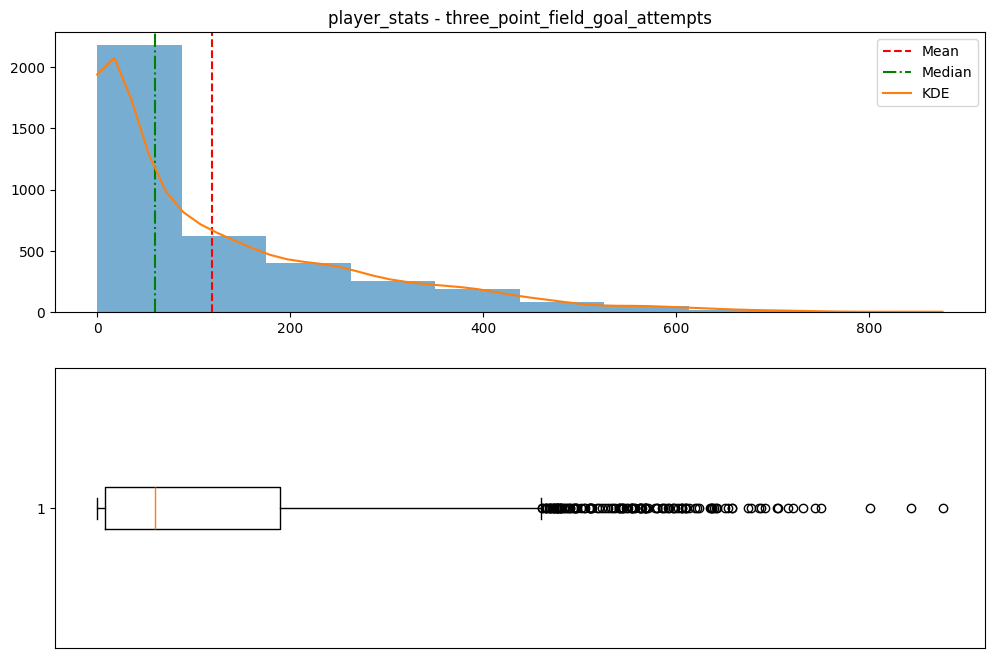

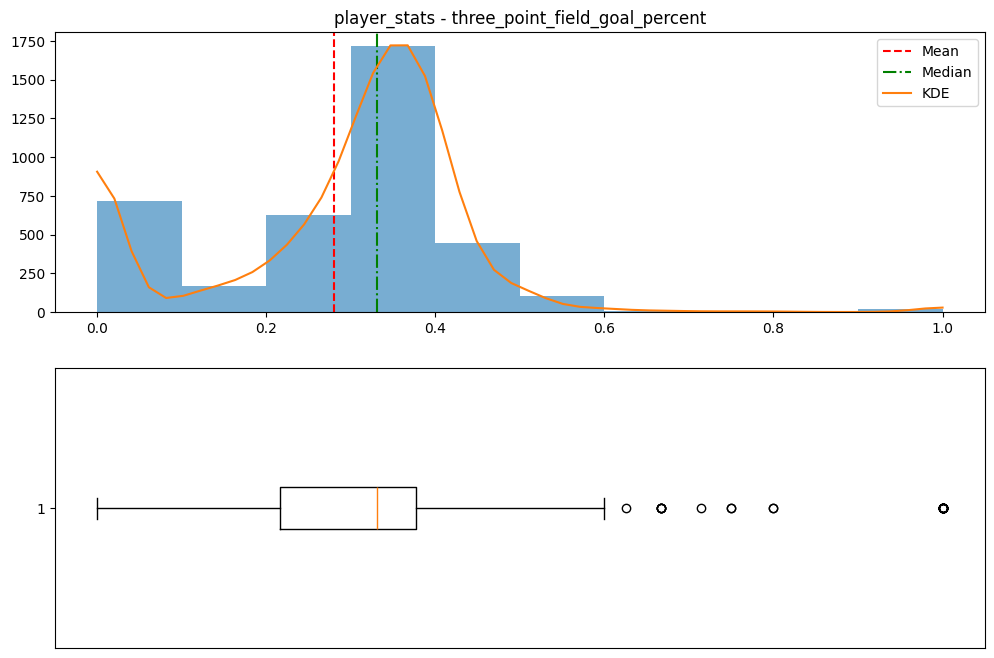

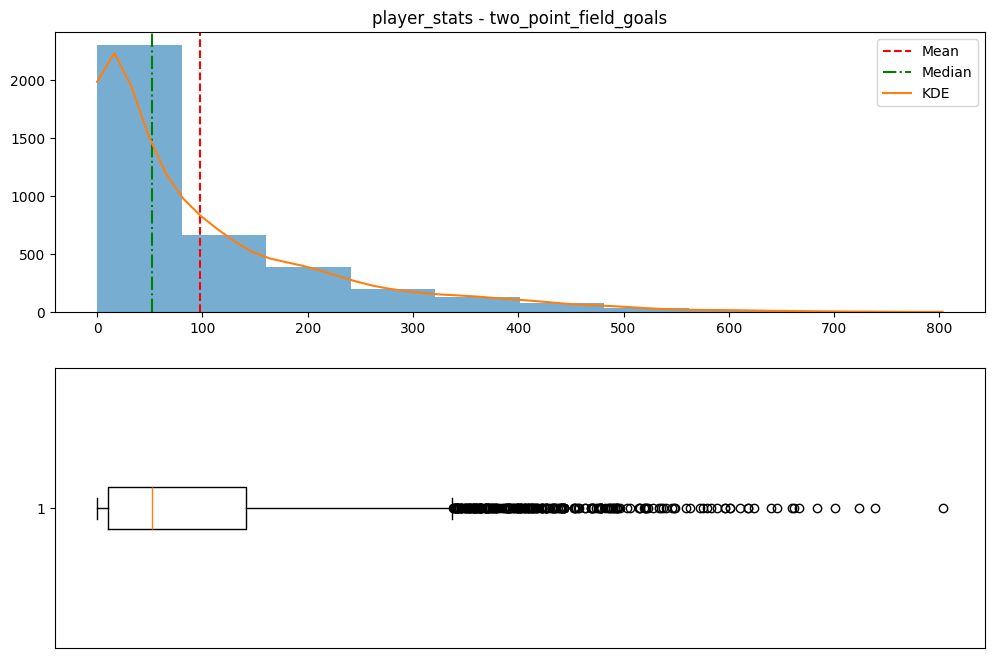

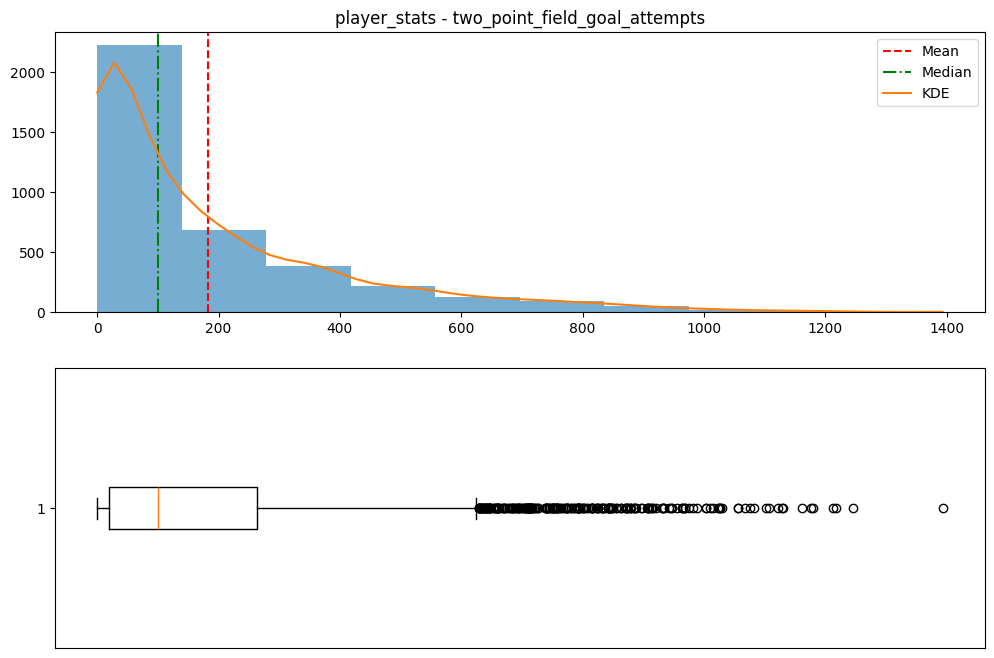

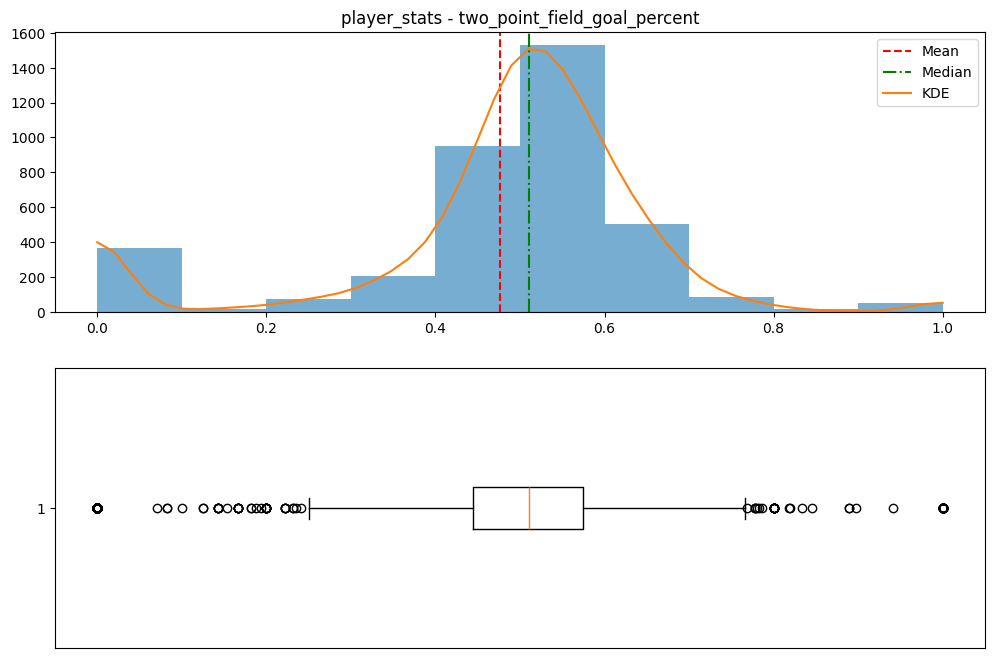

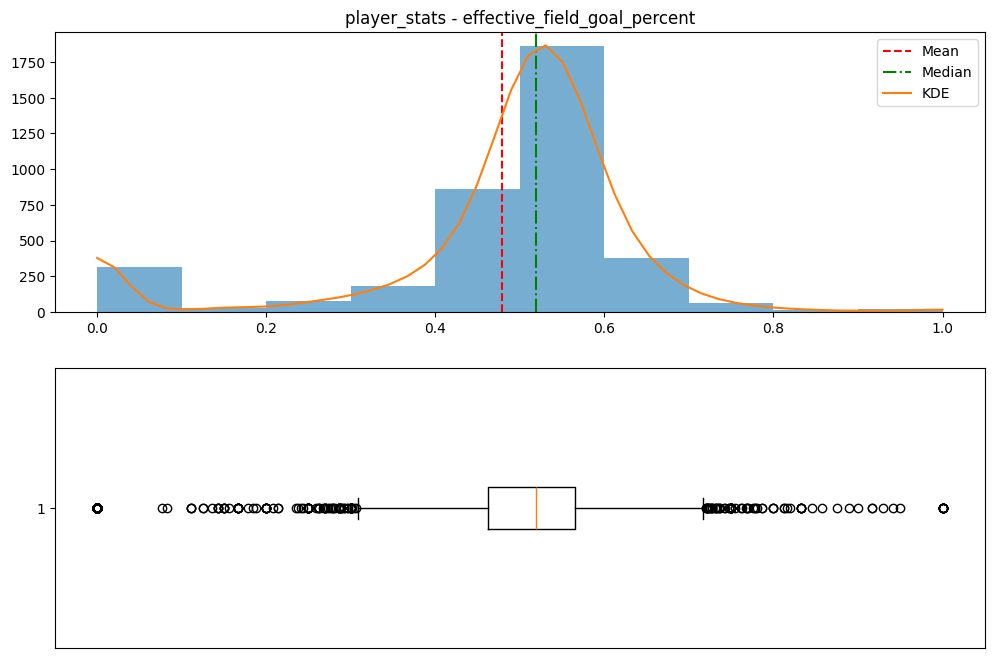

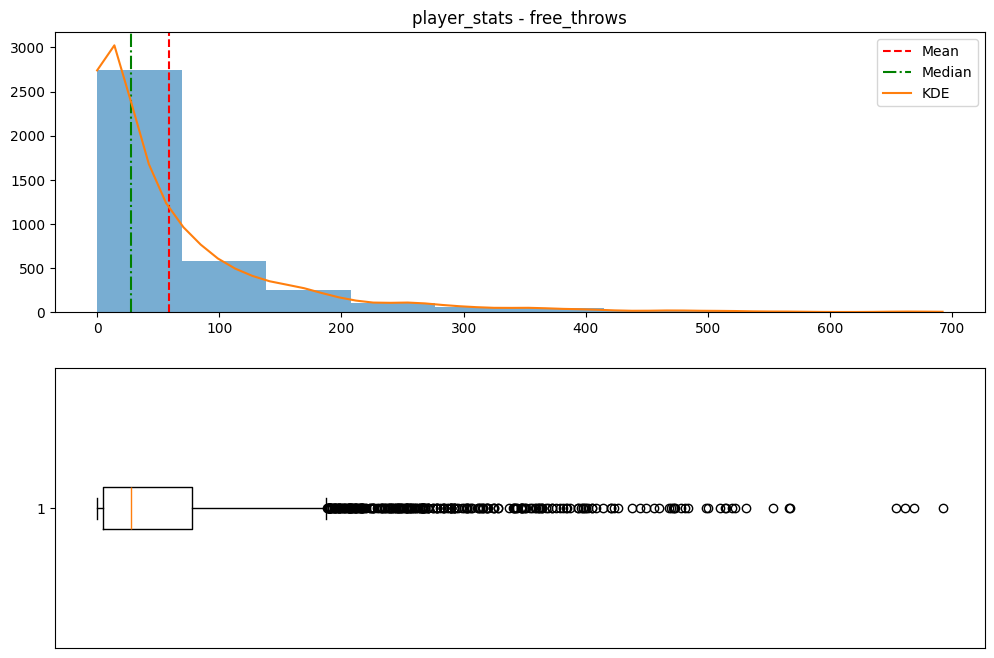

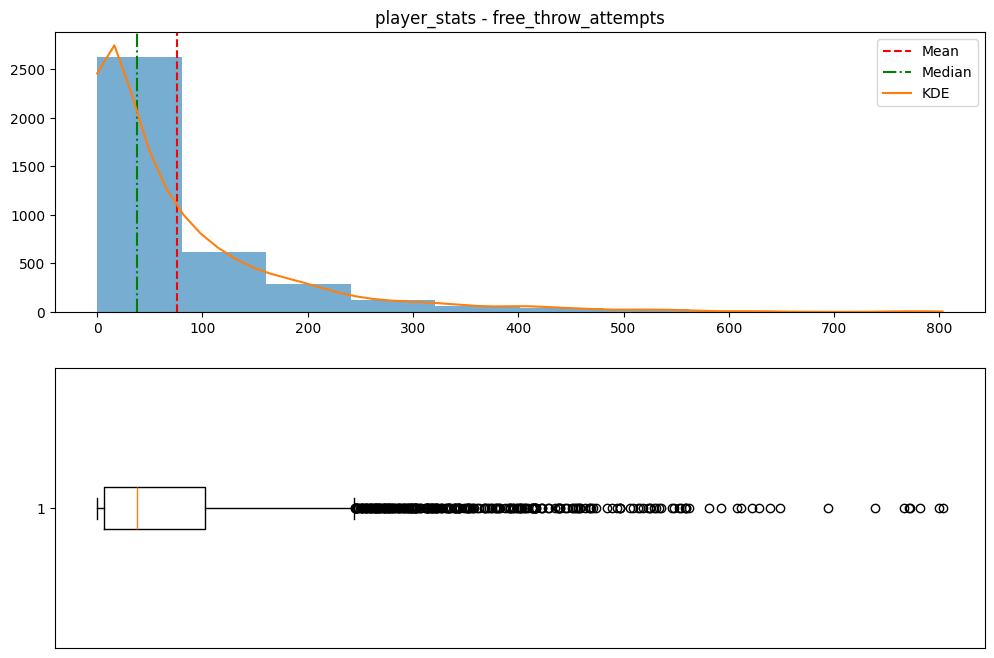

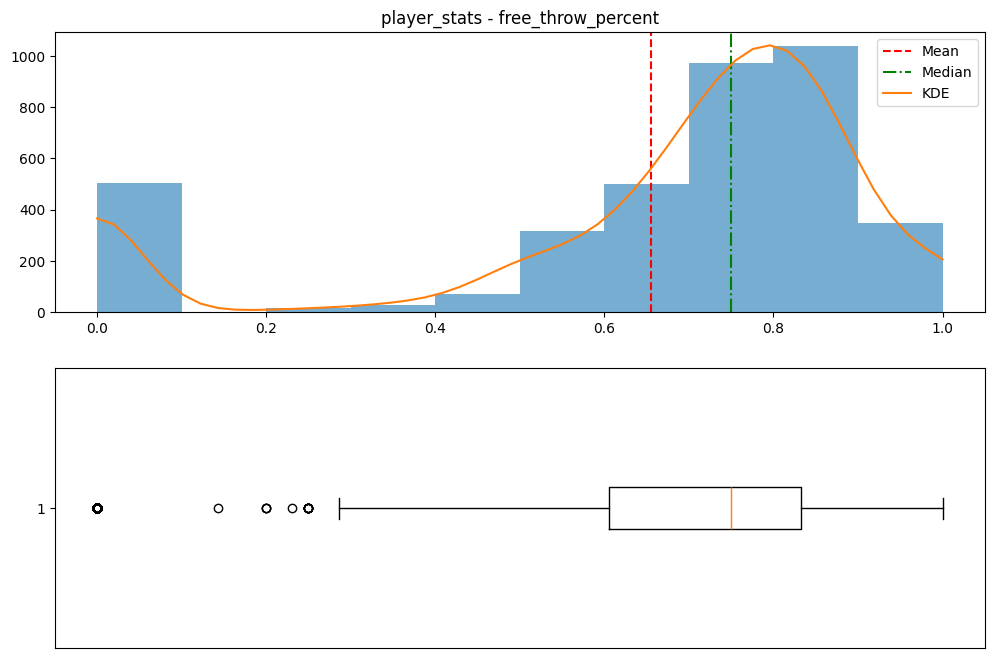

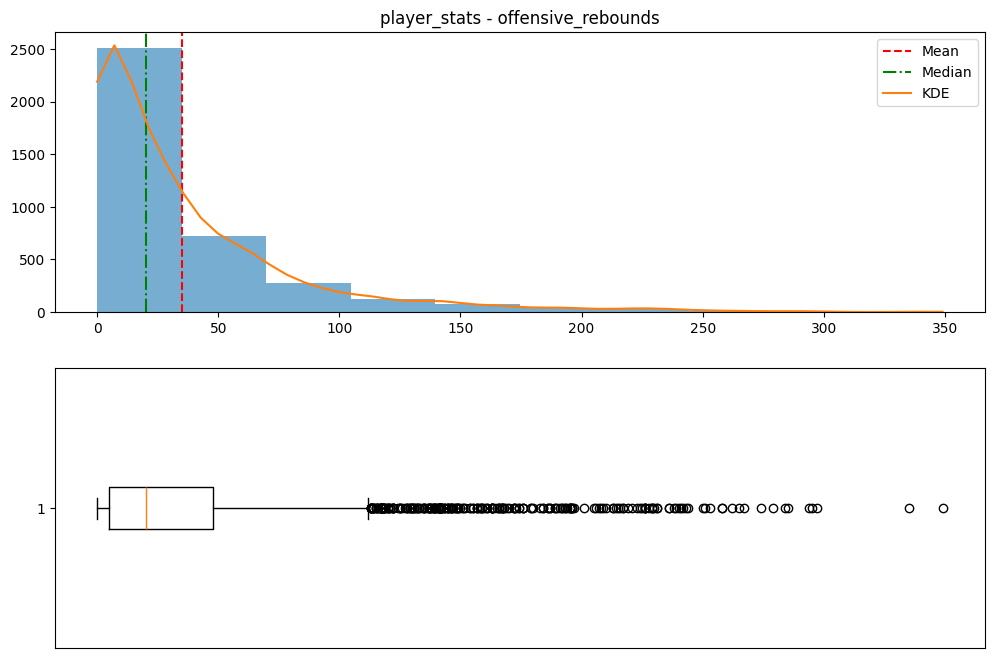

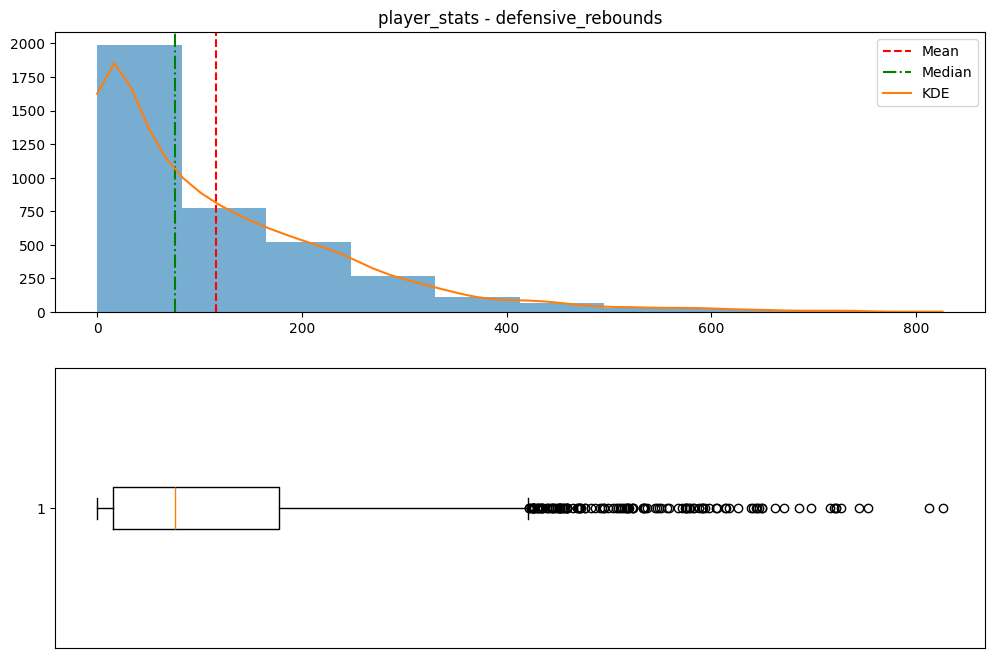

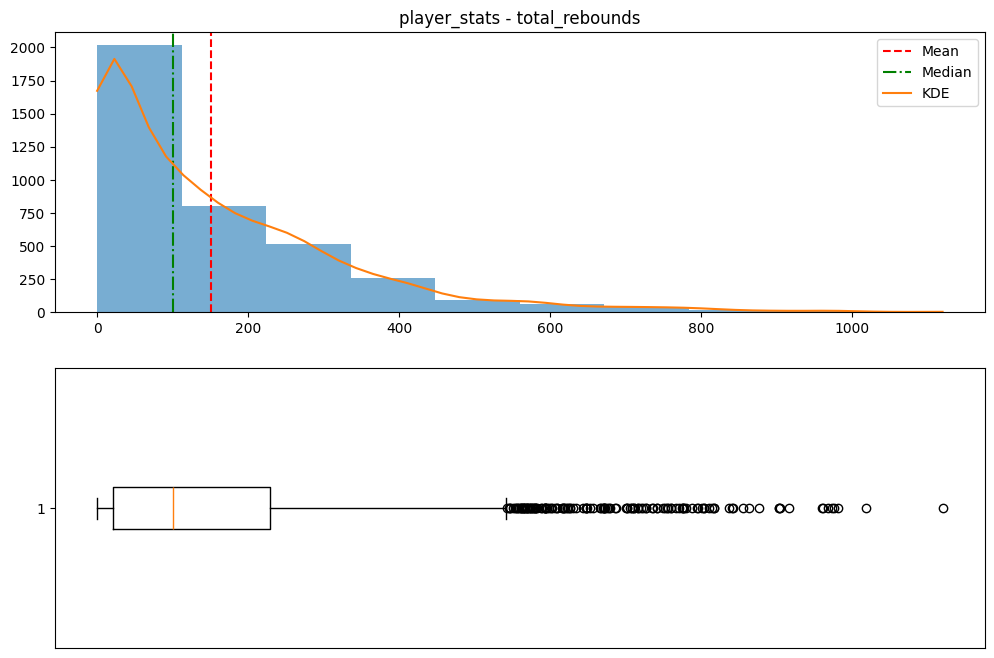

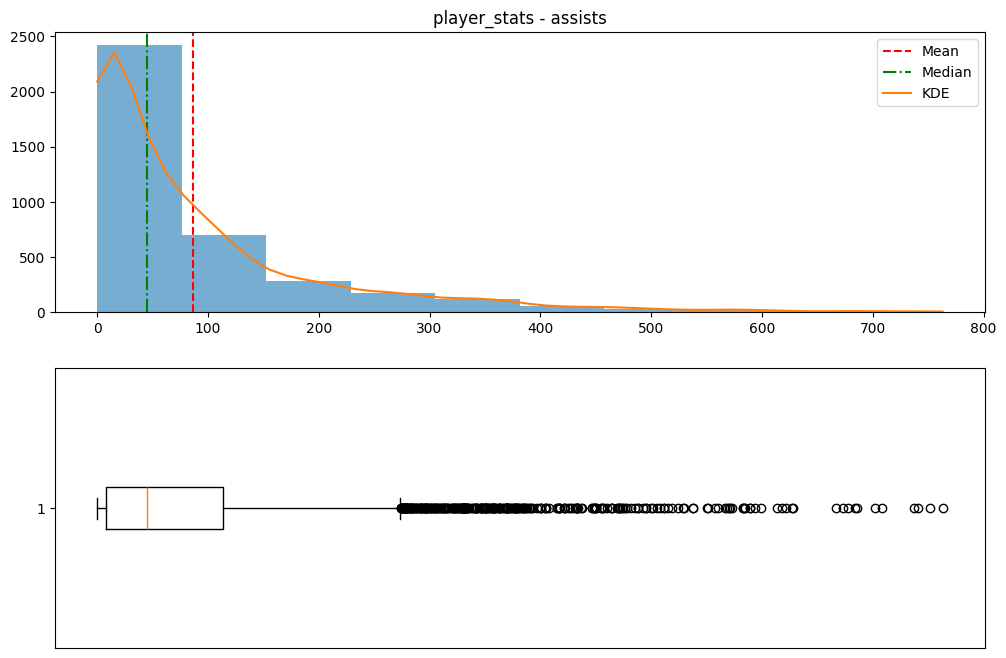

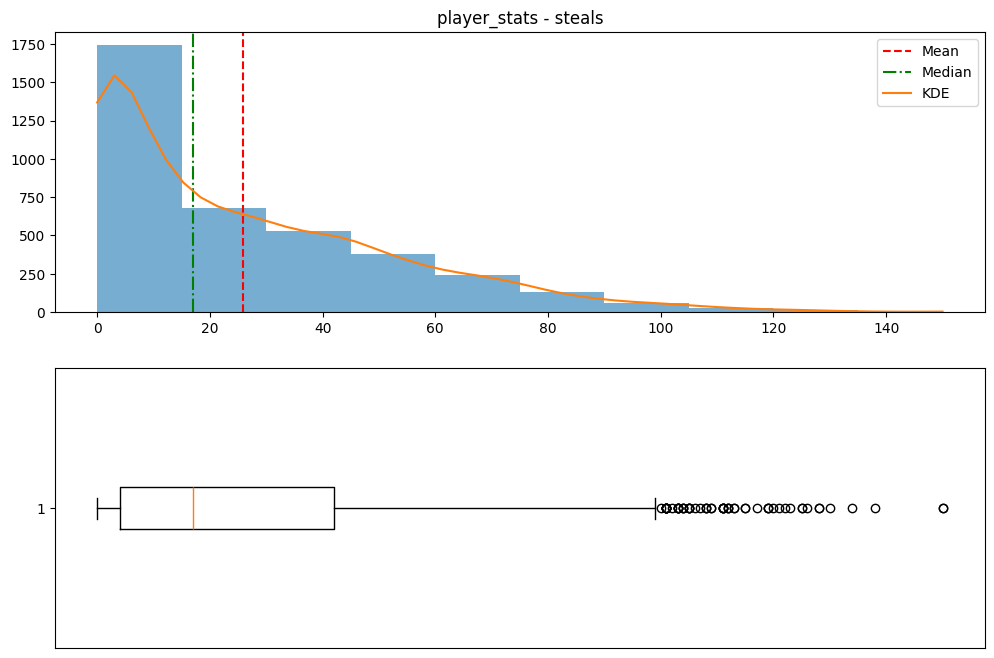

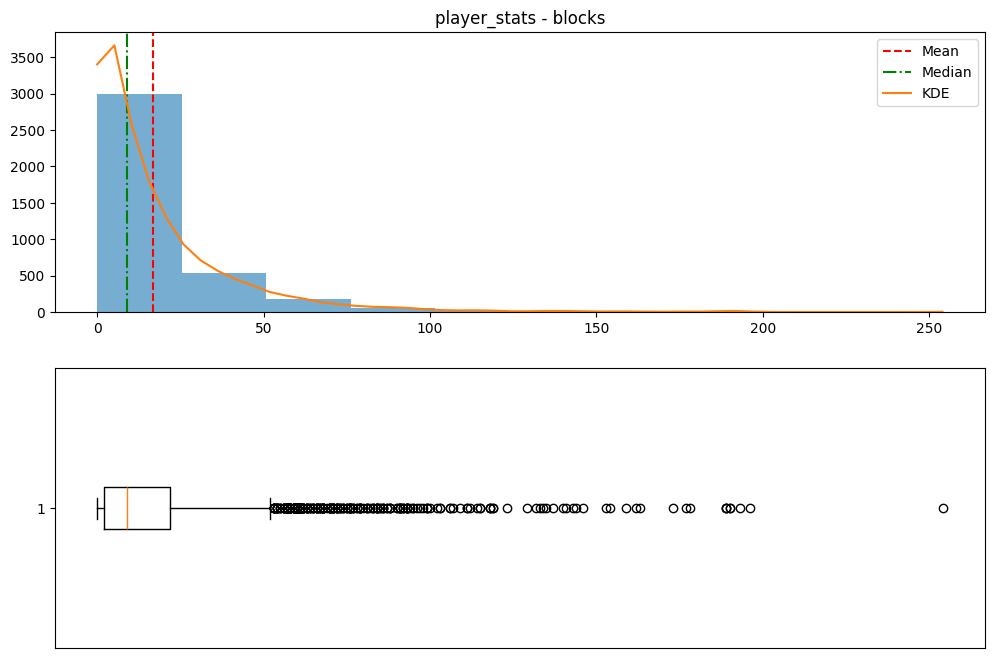

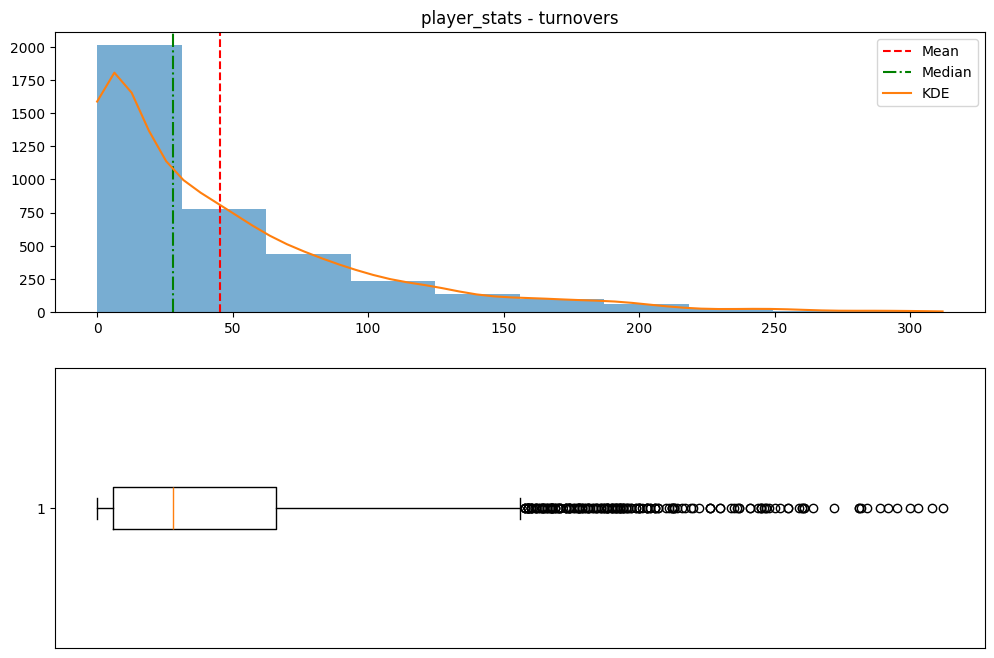

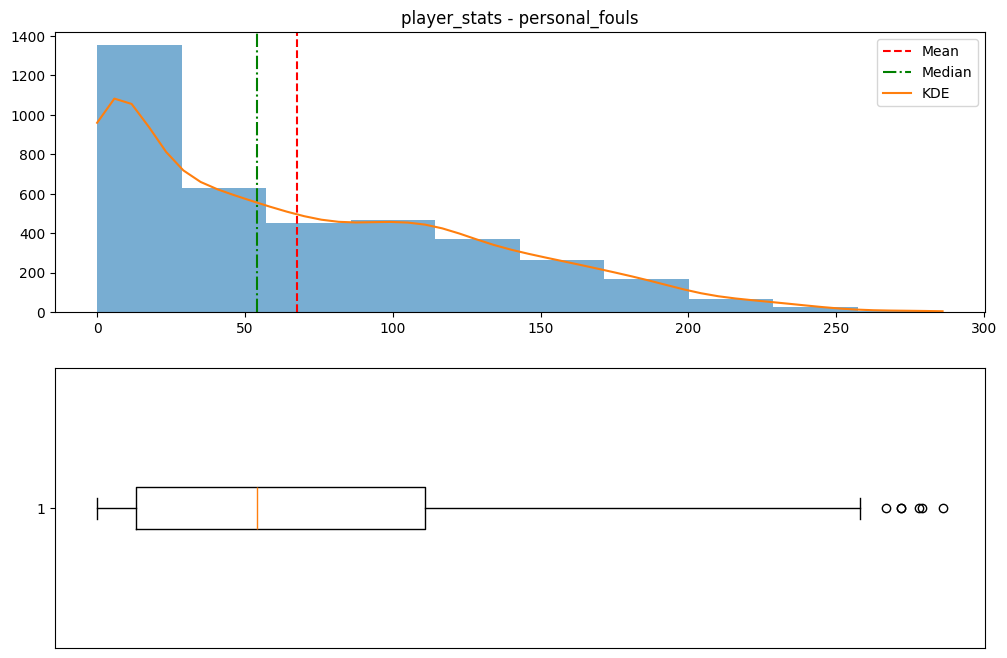

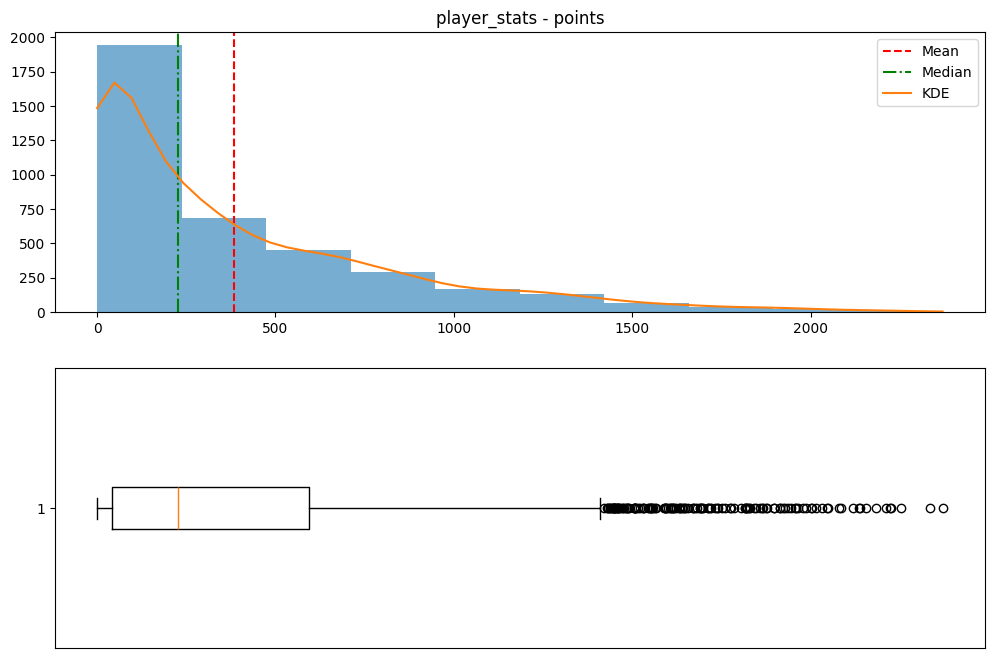

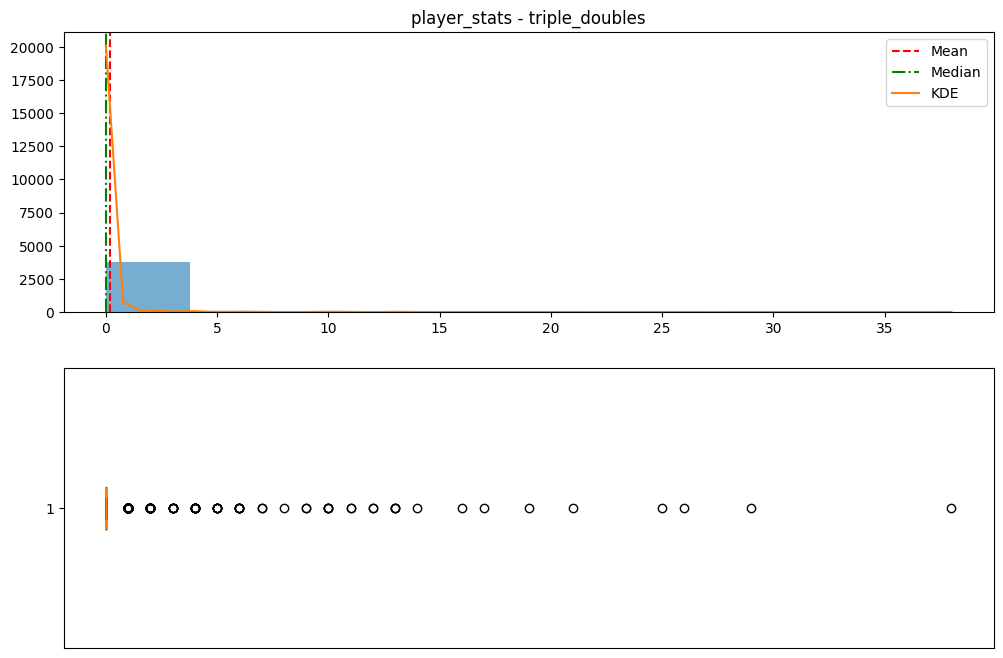

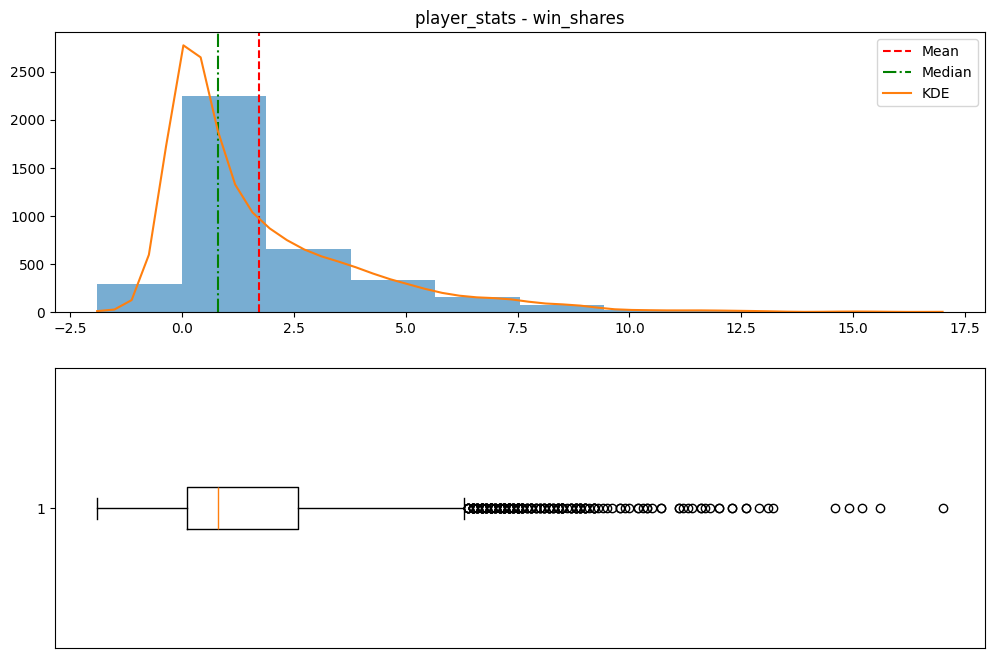

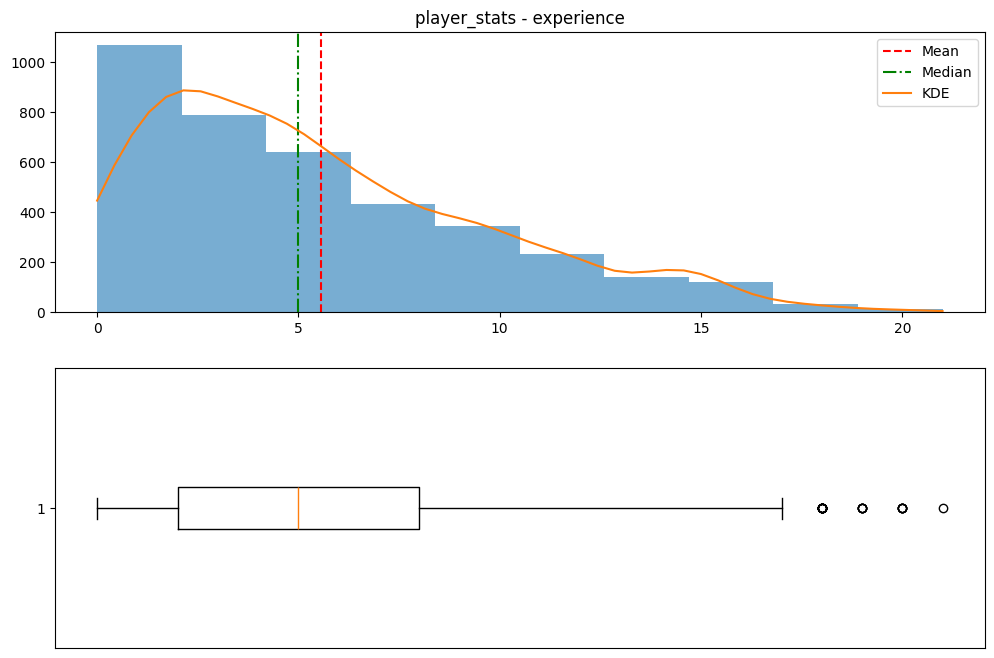

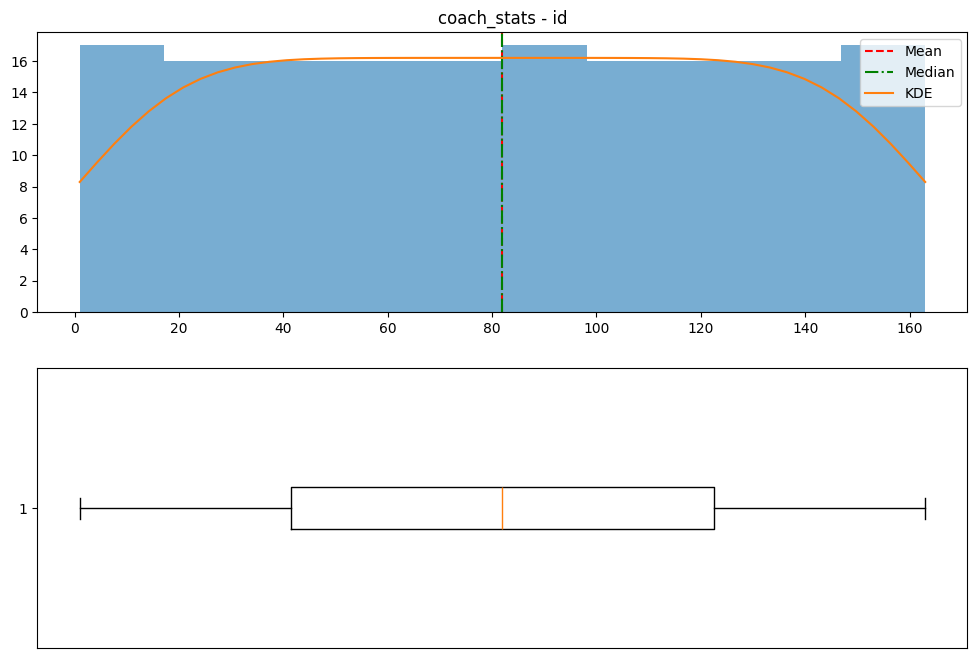

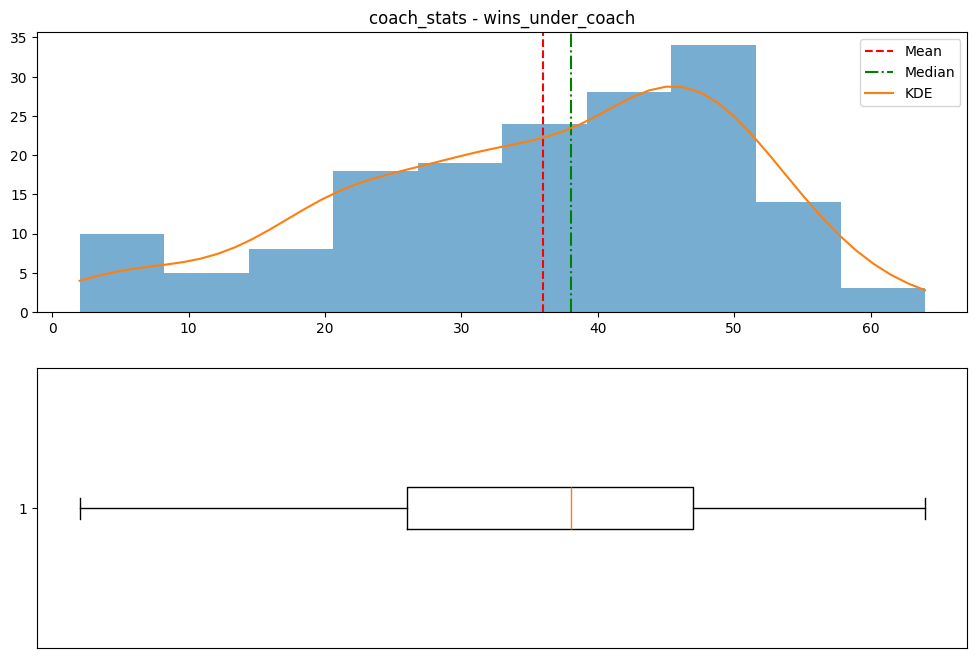

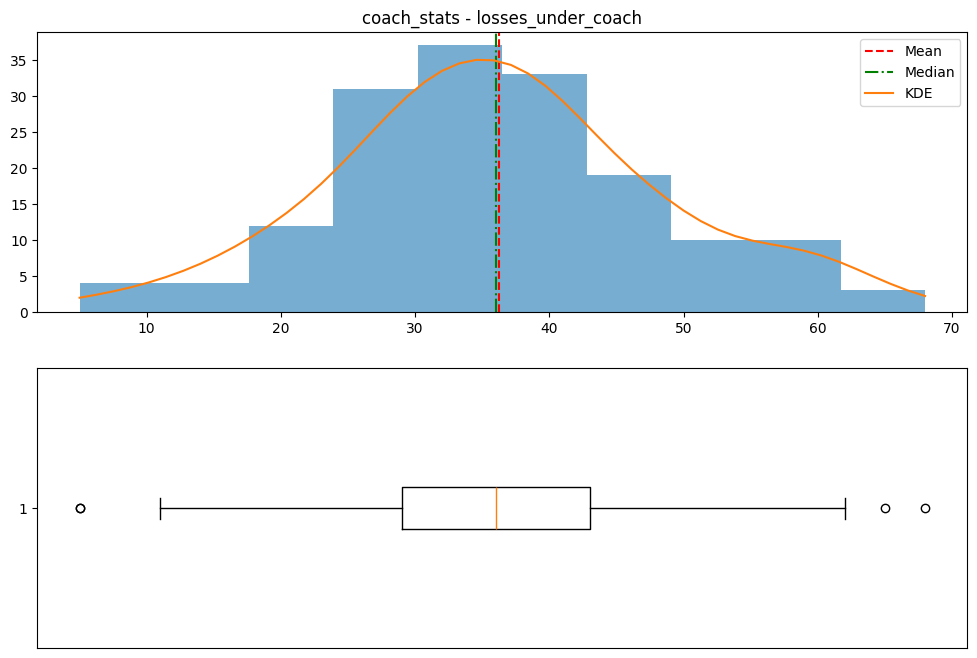

In [6]:
for name, df in dfs.items():
    plot_numeric_distributions(df, name)

In [7]:
def cleaning_dataframe(df, name, pk_cols, replacement="median", threshold=0.05):
   df_cleaned = df.copy()
    
   if pk_cols:
        df_cleaned = df_cleaned.drop_duplicates(subset=pk_cols)
    
   total_rows = len(df_cleaned)
   if total_rows == 0:
        return df_cleaned
        
   numeric_cols = []

   for col in df_cleaned.columns:
      dtype_name = df_cleaned[col].dtype.name

      if 'int' in dtype_name or 'float' in dtype_name:
         numeric_cols.append(col)
    
   for col in df_cleaned.columns:
        null_count = df_cleaned[col].isnull().sum()
        if null_count == 0:
            continue
            
        null_ratio = null_count / total_rows
        
        if null_ratio <= threshold:
            df_cleaned = df_cleaned.dropna(subset=[col])
        else:
            if col in numeric_cols:
                if replacement == "mean":
                    fill_value = df_cleaned[col].mean()
                elif replacement == "median":
                    fill_value = df_cleaned[col].median()
                else:
                    fill_value = 0
                df_cleaned[col] = df_cleaned[col].fillna(fill_value)
            else:
                df_cleaned[col] = df_cleaned[col].fillna("Unknown")
                
   return df_cleaned

In [8]:
def check_normality(data, alpha=0.05):
     if len(data) < 8:
        return False  

     stat, p_value = normaltest(data)

     return p_value > alpha

1.Question 1
1.1_Compare the height distribution of players on the Michael Jordan Trophy list with that of the season's top 50 players, based on statistics from the 2019–2020 season through the end of the 2023–2024 season.

In [9]:
#SQL Query

jordan_trophy = """
SELECT p.name, p.height, 'Jordan Trophy' AS label
FROM players p
JOIN award_season aws ON p.player_id = aws.player_id
JOIN awards a ON aws.award_id = a.award_id
WHERE a.name LIKE '%Michael Jordan Trophy%' 
  AND aws.season_id BETWEEN 2020 AND 2024;
"""

top_50_players = """
WITH ranked_players AS (
    SELECT 
        p.name,
        p.height,
        ps.season_id,
        ps.win_shares,
        RANK() OVER(
            PARTITION BY ps.season_id 
            ORDER BY ps.win_shares DESC
        ) AS rank
    FROM players p
    JOIN player_stats ps 
        ON p.player_id = ps.player_id
    WHERE ps.season_id BETWEEN 2020 AND 2024
)

SELECT
    name,
    height,
    'Top 50' AS label
FROM ranked_players
WHERE rank <= 50;
"""

jordan_trophy_df = pd.read_sql_query(jordan_trophy , conn)
top_50_players_df = pd.read_sql_query(top_50_players , conn)
df_q1 = pd.concat([jordan_trophy_df , top_50_players_df])
df_q1

,name,height,label
0,Giannis Antetokounmpo,211,Jordan Trophy
1,LeBron James,206,Jordan Trophy
2,James Harden,196,Jordan Trophy
3,Luka Dončić,203,Jordan Trophy
4,Kawhi Leonard,198,Jordan Trophy
...,...,...,...
249,Franz Wagner,208,Top 50
250,Clint Capela,208,Top 50
251,Jrue Holiday,193,Top 50
252,Karl-Anthony Towns,213,Top 50


1.2_Visualization


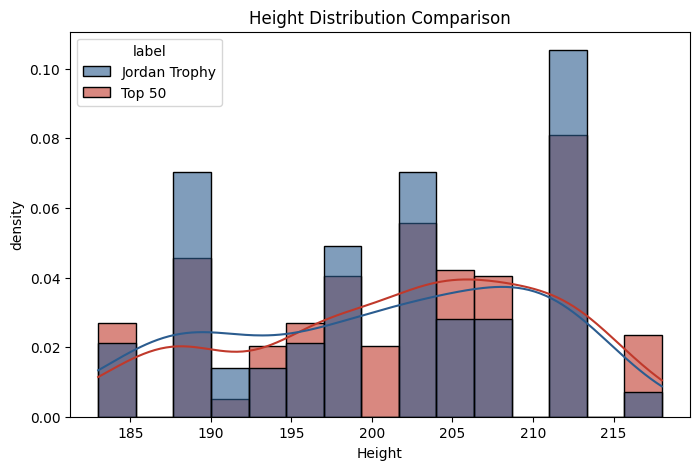

In [10]:
palette = {
    'Jordan Trophy': '#2b5c8f',  
    'Top 50': '#c0392b'        
}

plt.figure(figsize=(8,5))

sns.histplot(
    data=df_q1,
    x="height",
    hue="label",
    kde=True,
    bins=15,
    stat="density",
    alpha=0.6,
    common_norm=False,
    palette=palette
    )

plt.title("Height Distribution Comparison")
plt.xlabel("Height")
plt.ylabel("density")
plt.show()

2.Question 2 2.1_Compare Experience distribution and height in last two seasons between champion team and 15 best players

In [11]:
last_two_seasons = sorted(dfs["seasons"]["season_id"].unique())[-2:]
print(f"Last Two Seasons: {last_two_seasons}")

comparison_data = []

for season in last_two_seasons:
    season_team_stats = dfs["team_stats"][dfs["team_stats"]["season_id"] == season]
    
    champ_rows = season_team_stats[
        season_team_stats["playoff_result"].astype(str).str.contains("Finals|Champion|1", case=False, na=False)
    ]
    
    if len(champ_rows) > 0:
        champ_id = champ_rows.iloc[0]["team_id"]
    else:
        champ_id = season_team_stats.sort_values(by="wins", ascending=False).iloc[0]["team_id"]

    champ_players_stats = dfs["player_stats"][
        (dfs["player_stats"]["season_id"] == season) & 
        (dfs["player_stats"]["team_id"] == champ_id)
    ]
    
    top15_players_stats = dfs["player_stats"][
        dfs["player_stats"]["season_id"] == season
    ].sort_values(by="points", ascending=False).head(15)

    champ_merged = champ_players_stats.merge(
        dfs["players"][["player_id", "height", "name"]], 
        on="player_id", 
        how="left"
    )
    top15_merged = top15_players_stats.merge(
        dfs["players"][["player_id", "height", "name"]], 
        on="player_id", 
        how="left"
    )
    
    champ_merged["Group"] = "Champion Team"
    champ_merged["Season"] = season
    
    top15_merged["Group"] = "15 Best Players"
    top15_merged["Season"] = season
    
    comparison_data.append(champ_merged)
    comparison_data.append(top15_merged)

df_q2 = pd.concat(comparison_data, ignore_index=True)

df_q2["height"] = pd.to_numeric(df_q2["height"], errors="coerce")
df_q2["experience"] = pd.to_numeric(df_q2["experience"], errors="coerce")
df_q2

Last Two Seasons: [np.int64(2023), np.int64(2024)]


,id,season_id,player_id,team_id,games,games_started,minutes_played,field_goals,field_goal_attempts,field_goal_percent,...,turnovers,personal_fouls,points,triple_doubles,win_shares,experience,height,name,Group,Season
0,163,2023,brownja02,BOS,67,67,2405,679,1383,0.491,...,197,172,1784,0,5.0,7,198,Jaylen Brown,Champion Team,2023
1,205,2023,smartma01,BOS,61,61,1957,250,602,0.415,...,143,172,703,0,3.7,9,190,Marcus Smart,Champion Team,2023
2,210,2023,tatumja01,BOS,74,74,2732,727,1559,0.466,...,213,160,2225,1,10.5,6,203,Jayson Tatum,Champion Team,2023
3,243,2023,willigr01,BOS,79,23,2045,216,476,0.454,...,82,192,641,0,4.4,4,201,Grant Williams,Champion Team,2023
4,250,2023,williro04,BOS,35,20,824,127,170,0.747,...,34,68,279,0,3.8,5,206,Robert Williams,Champion Team,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,2322,2024,derozde01,CHI,79,79,2989,650,1355,0.480,...,135,161,1897,0,9.2,14,198,DeMar DeRozan,15 Best Players,2024
63,1475,2024,davisan02,LAL,76,76,2700,713,1283,0.556,...,159,177,1876,2,11.8,11,208,Anthony Davis,15 Best Players,2024
64,2244,2024,bookede01,PHO,68,68,2447,642,1305,0.492,...,178,206,1841,0,9.2,8,196,Devin Booker,15 Best Players,2024
65,1497,2024,jamesle01,LAL,71,71,2504,685,1269,0.540,...,245,78,1822,5,8.5,20,206,LeBron James,15 Best Players,2024


2.2_ Visualization

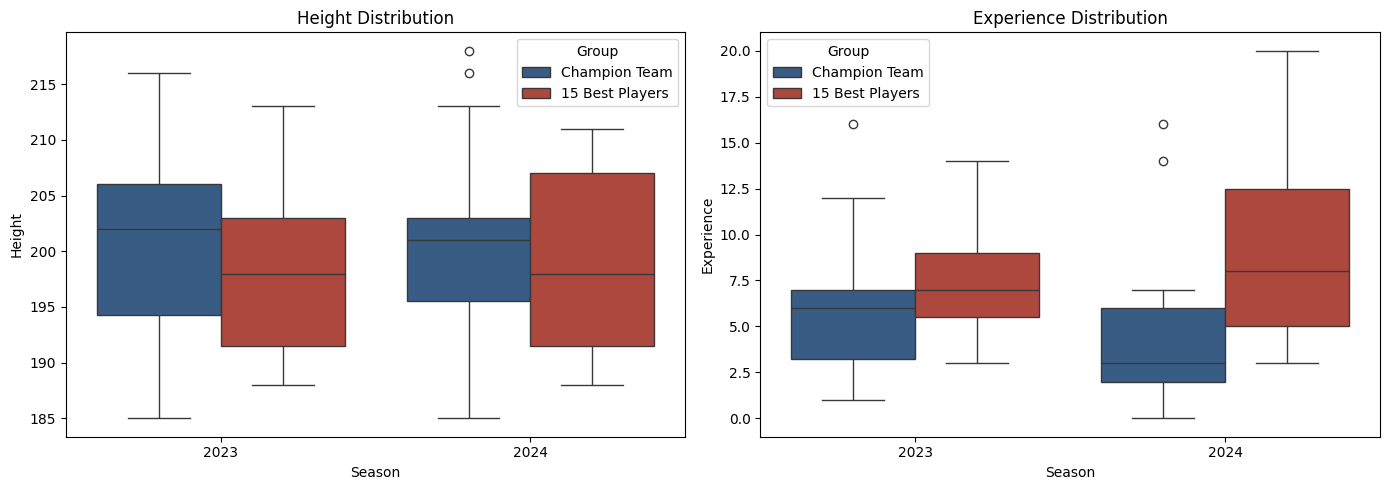

In [12]:
plt.figure(figsize=(14, 5))

#height plot
plt.subplot(1, 2, 1)
sns.boxplot(data=df_q2, x="Season", y="height", hue="Group", palette=["#2b5c8f", "#c0392b"])
plt.title("Height Distribution")
plt.xlabel("Season")
plt.ylabel("Height")

#experience plot
plt.subplot(1, 2, 2)
sns.boxplot(data=df_q2, x="Season", y="experience", hue="Group", palette=["#2b5c8f", "#c0392b"])
plt.title("Experience Distribution")
plt.xlabel("Season")
plt.ylabel("Experience")

plt.tight_layout()
plt.show()

In [13]:
print(df_q2.groupby(["Season", "Group"])[["height", "experience"]].agg(["mean", "median"]))

                            height        experience       
                              mean median       mean median
Season Group                                               
2023   15 Best Players  198.400000  198.0   7.333333    7.0
       Champion Team    200.277778  202.0   6.166667    6.0
2024   15 Best Players  199.466667  198.0   8.866667    8.0
       Champion Team    200.578947  201.0   4.684211    3.0


3.Question 3
3.1_A recommendation of three players for the Point Guard (PG) position, based on the highest number of appearances in the Michael Jordan Trophy.


In [14]:
#SQL Query
point_guards_jordan = """
SELECT p.player_id, p.name, COUNT(aws.id) AS trophy_count
FROM players p
JOIN player_position pp ON p.player_id = pp.player_id
JOIN award_season aws ON p.player_id = aws.player_id
JOIN awards a ON aws.award_id = a.award_id
WHERE pp.position LIKE '%Point Guard%'
  AND a.name LIKE '%Michael Jordan Trophy%'
  AND aws.season_id BETWEEN 2020 AND 2024
GROUP BY p.player_id, p.name
ORDER BY trophy_count DESC, p.name ASC
LIMIT 3;
"""
point_guards_jordan_df = pd.read_sql_query(point_guards_jordan , conn)
point_guards_jordan_df

,player_id,name,trophy_count
0,doncilu01,Luka Dončić,5
1,paulch01,Chris Paul,3
2,jamesle01,LeBron James,3


3.2_Visualization

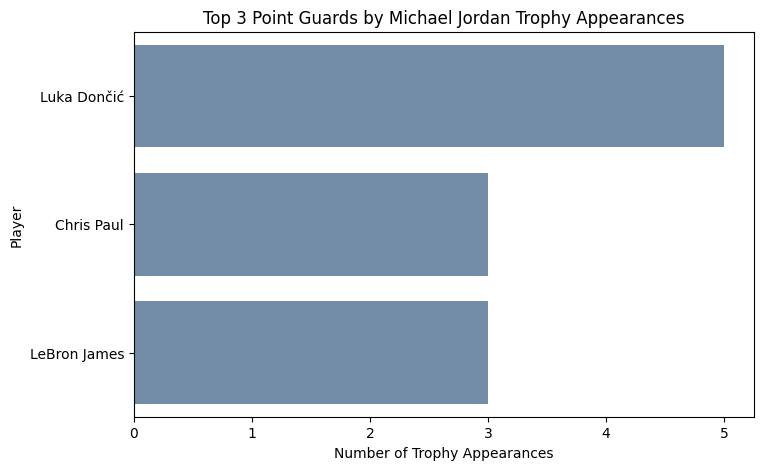

In [15]:
plt.figure(figsize=(8,5))

sns.barplot(
    data= point_guards_jordan_df,
    y ="name" , 
    x ="trophy_count",
    color='#2b5c8f',
    alpha = 0.7
)

plt.title("Top 3 Point Guards by Michael Jordan Trophy Appearances")
plt.xlabel("Number of Trophy Appearances")
plt.ylabel("Player")

plt.show()


4.Q 4


In [16]:
#SQL Query

hypothesis_1 = """
WITH RankedSeason AS (
    SELECT 
        p.player_id,
        p.height,
        p.weight,
        ps.season_id,
        CAST(p.height AS REAL) / p.weight AS agility,
        ROW_NUMBER() OVER (
            PARTITION BY ps.season_id 
            ORDER BY ps.win_shares DESC
        ) AS rank
    FROM players p
    JOIN player_stats ps 
        ON p.player_id = ps.player_id
)

SELECT 
    season_id,
    agility,
    CASE 
        WHEN season_id IN (2021, 2022) THEN 'Past_Group'
        WHEN season_id IN (2023, 2024) THEN 'Recent_Group'
    END AS period
FROM RankedSeason
WHERE rank <= 20
  AND season_id IN (2021, 2022, 2023, 2024);
"""

hypothesis_2 = """
WITH DataWithAge AS (
    SELECT 
        ps.season_id,
        ps.experience,
        (ps.season_id - CAST(STRFTIME('%Y', p.birthdate) AS INTEGER)) AS age
    FROM players p
    JOIN player_stats ps 
        ON p.player_id = ps.player_id
    JOIN seasons s 
        ON ps.season_id = s.season_id
    WHERE ps.team_id = s.champion_id
      AND ps.season_id IN (2021, 2022, 2023, 2024)
      AND ps.games > 0
)

SELECT 
    season_id,
    experience,
    age,
    CAST(experience AS REAL) / age AS innate_ability,
    CASE 
        WHEN season_id IN (2021, 2022) THEN 'Past_Group'
        WHEN season_id IN (2023, 2024) THEN 'Recent_Group'
    END AS period
FROM DataWithAge;
"""

h1_df = pd.read_sql_query( hypothesis_1,conn)
h2_df = pd.read_sql_query( hypothesis_2,conn)

In [17]:
def hypothesis_test(df,value_col,group_col,group1,group2,alpha=0.05):
    data1 = df[df[group_col] == group1][value_col].dropna()
    data2 = df[df[group_col] == group2][value_col].dropna()


    normal1 = check_normality(data1, alpha)
    normal2 = check_normality(data2, alpha)


    if normal1 and normal2:

        test_name = "Independent T-test"

        stat, p_value = ttest_ind(
            data1,
            data2,
            equal_var=False,
            alternative="greater"
        )

    else:

        test_name = "Mann Whitney U"

        stat, p_value = mannwhitneyu(
            data1,
            data2,
            alternative="greater"
        )


    result = pd.DataFrame({
        "Variable": [value_col],
        "Test": [test_name],
        "Group1": [group1],
        "Group2": [group2],
        "Normal_Group1": [normal1],
        "Normal_Group2": [normal2],
        "Statistic": [stat],
        "P_Value": [p_value],
        "Reject_H0": [p_value < alpha]
    })

    return result

     

4.1.1_hypothesis 1
The average agility of the top 20 players in recent seasons has increased compared to previous seasons.
H0​:μRecent​≤μPast​
H1​:μRecent​>μPast​

In [18]:
h1_result = hypothesis_test(
    df=h1_df,
    value_col="agility",
    group_col="period",
    group1="Past_Group",
    group2="Recent_Group"
)

h1_result

,Variable,Test,Group1,Group2,Normal_Group1,Normal_Group2,Statistic,P_Value,Reject_H0
0,agility,Mann Whitney U,Past_Group,Recent_Group,False,True,586.0,0.971814,False


4.1.2_Visualization

4.2.1_hypothesis 2
The innate ability of the champion team's players has increased over the last two seasons compared to the two seasons prior.
H0​:μRecent​≤μPast​
H1​:μRecent​>μPast​

In [19]:
h2_result = hypothesis_test(
    df=h2_df,
    value_col="innate_ability",
    group_col="period",
    group1="Past_Group",
    group2="Recent_Group"
)
h2_result

,Variable,Test,Group1,Group2,Normal_Group1,Normal_Group2,Statistic,P_Value,Reject_H0
0,innate_ability,Independent T-test,Past_Group,Recent_Group,True,True,1.515047,0.067017,False


4.2.2_Visualization


5.1
Is a team where points are shared among everyone more successful, or a team where a single superstar scores all the points?

In [21]:
#SQL Query
dependency = """
WITH TeamTotalPoints AS (
    SELECT
        season_id,
        team_id,
        SUM(points) AS total_team_points
    FROM player_stats
    GROUP BY season_id, team_id
),

PlayerMaxPoints AS (
    SELECT
        season_id,
        team_id,
        MAX(points) AS max_player_points
    FROM player_stats
    GROUP BY season_id, team_id
)

SELECT
    t.season_id,
    t.team_id,
    ts.wins,

    ROUND(
        CAST(m.max_player_points AS REAL)
        / t.total_team_points * 100,
        2
    ) AS dependency_percentage

FROM TeamTotalPoints t

JOIN PlayerMaxPoints m
ON t.season_id = m.season_id
AND t.team_id = m.team_id

JOIN team_stats ts
ON t.season_id = ts.season_id
AND t.team_id = ts.team_id;
"""
dependency_df = pd.read_sql_query(dependency , conn)
dependency_df

,season_id,team_id,wins,dependency_percentage
0,2020,ATL,20,23.74
1,2020,BOS,48,18.91
2,2020,BRK,35,16.38
3,2020,CHI,22,22.03
4,2020,CHO,23,17.12
...,...,...,...,...
145,2024,SAC,46,20.57
146,2024,SAS,22,16.56
147,2024,TOR,25,12.93
148,2024,UTA,31,15.37


In [22]:
def correlation_test(df, col1, col2, alpha=0.05):

    data = df[[col1, col2]].dropna()

    x = data[col1]
    y = data[col2]

    normal1 = check_normality(x, alpha)
    normal2 = check_normality(y, alpha)

    if normal1 and normal2:

        test_name = "Pearson"

        corr, p_value = pearsonr(x, y)

    else:

        test_name = "Spearman"

        corr, p_value = spearmanr(x, y)

    result = pd.DataFrame({
        "Variable_1": [col1],
        "Variable_2": [col2],
        "Test": [test_name],
        "Normal_1": [normal1],
        "Normal_2": [normal2],
        "Correlation": [round(corr, 4)],
        "P_Value": [round(p_value, 6)],
        "Significant": [p_value < alpha]
    })

    return result

In [23]:
correlation_result = correlation_test(
    dependency_df,
    "dependency_percentage",
    "wins"
)

correlation_result

,Variable_1,Variable_2,Test,Normal_1,Normal_2,Correlation,P_Value,Significant
0,dependency_percentage,wins,Spearman,True,False,0.4374,0.0,True


5.2
Visualization

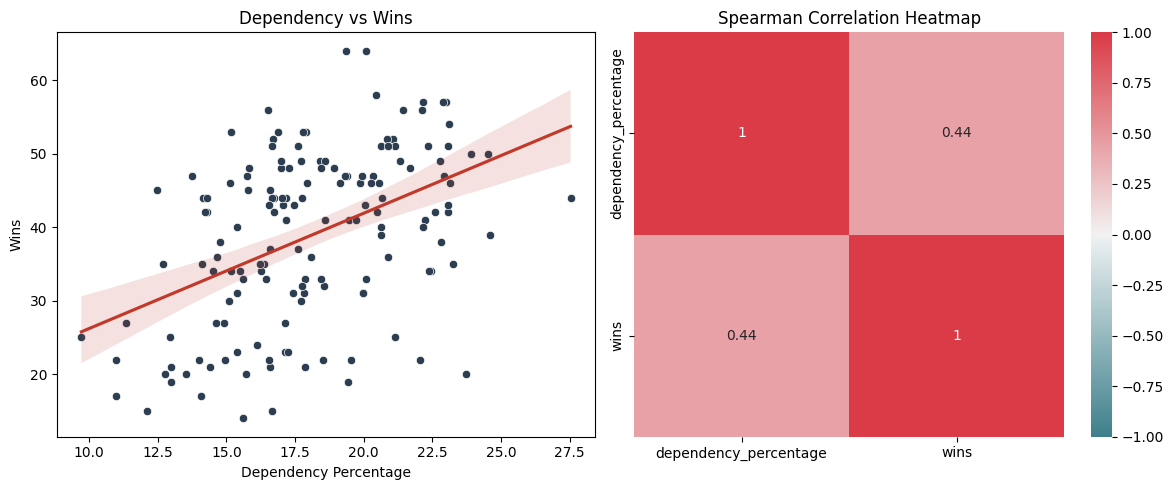

In [29]:
corr = dependency_df[["dependency_percentage", "wins"]].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter Plot
sns.scatterplot(
    data=dependency_df,
    x="dependency_percentage",
    y="wins",
    color="#2c3e50",
    ax=axes[0]
)

sns.regplot(
    data=dependency_df,
    x="dependency_percentage",
    y="wins",
    scatter=False,
    color="#c0392b",
    ax=axes[0]
)

axes[0].set_title("Dependency vs Wins")
axes[0].set_xlabel("Dependency Percentage")
axes[0].set_ylabel("Wins")


# Heatmap
sns.heatmap(
    corr,
    annot=True,
    cmap=sns.diverging_palette(210, 10, as_cmap=True),
    vmin=-1,
    vmax=1,
    ax=axes[1]
)

axes[1].set_title("Spearman Correlation Heatmap")

plt.tight_layout()
plt.show()

A moderate positive correlation was observed between team dependency on a top scorer and team success, indicating that teams relying more on star players tend to achieve more wins.